# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados  
**Grupo:** João Marcos Oliveira Neves (2024008644), Júlia Borba Fonseca de Souza (2023117580), Laura Martins Froede (2023087877), Matheus Soares dos Santos de Freitas (2024080043)  
**Dataset:** Credit Card Dataset for Clustering 
**Tarefa de mineração:** Agrupamento
**Data da entrega:** 31/05/2026

---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo deve:

1. corrigir erros e limitações identificados na Fase 2;
2. consolidar a solução técnica efetivamente implementada;
3. executar a modelagem final;
4. avaliar criticamente os resultados;
5. comparar três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

> **Importante:** este notebook é um modelo. Ele contém placeholders e trechos de código genéricos. O grupo deve adaptar tudo ao dataset, à tarefa e às decisões reais tomadas no trabalho.

# Como usar este notebook

Este notebook foi estruturado para orientar uma boa entrega final, sem substituir o trabalho do grupo.

Use os campos marcados como:

- `[INSERIR ...]`
- `[DESCREVER ...]`
- `[JUSTIFICAR ...]`
- `[ANALISAR ...]`
- `[PREENCHER ...]`

como indicações de conteúdo que deve ser produzido pelo grupo.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs.

Na Fase 3, o foco passa a ser a **solução final consolidada**, isto é:

- quais sugestões da LLM foram incorporadas;
- quais foram corrigidas;
- quais foram rejeitadas;
- quais algoritmos e parâmetros foram realmente usados;
- quais resultados foram efetivamente obtidos;
- como os resultados se relacionam ao problema de negócio e às diretrizes de IA responsável.

Não é necessário repetir todos os links completos das conversas da Fase 2, mas a comparação entre baseline, guiada e solução final deve permanecer clara.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | Credit Card Dataset for Clustering |
| Link público do dataset | https://www.kaggle.com/datasets/arjunbhasin2013/ccdata |
| Número de linhas | 8950 |
| Número de colunas | 18 |
| Tarefa de mineração | Agrupamento |
| Diretriz 1 de IA responsável | Explicabilidade |
| Diretriz 2 de IA responsável | Justiça e Viés |
| LLM usada na Fase 2 — baseline | Gemini Pro |
| LLM usada na Fase 2 — guiada | Gemini Pro |
| Notebook da Fase 2 | https://github.com/Doctor-Math/TPs-Mineracao-de-Dados/blob/VariableMath/notebooks/tp2/TP2_Fase2_Grupo6.ipynb |

## Resumo das decisões herdadas da Fase 2

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
|---|---|---|---|
| Imputação de valores ausentes em MINIMUM_PAYMENTS usando a Mediana | Trilha B (Guiada) | Sim | A Trilha A sugeriu a exclusão cega de registros nulos, o que descartaria dados cruciais de clientes recém-nascidos na base ou inativos. A Trilha B demonstrou que manter os registros via imputação por mediana protege o dataset contra viés de sobrevivência. |
| Transformação de escala utilizando log1p + RobustScaler | Trilha B (Guiada) | Sim | O dataset possui variáveis financeiras de cauda longa altamente assimétricas (poucos usuários com gastos massivos e saques extremos). A Trilha A recomendou o StandardScaler, que sofre distorções severas com outliers legítimos. O RobustScaler (baseado em quartis) estabilizou a influência de grandes devedores nos centroides. |
| Retenção e auditoria de outliers através do método IQR (sem exclusão automática) | Grupo / Trilha B | Sim | O grupo adaptou a função básica da LLM para atuar exclusivamente como ferramenta de diagnóstico de vulnerabilidade econômica e comportamento extremo (CASH_ADVANCE), proibindo a remoção sistemática de clientes sob uma ótica comercial punitiva. |
| Definição de Hiperparâmetros Fixos e Reprodutíveis no K-Means | Trilha B (Guiada) | Sim | Garantiu a reprodutibilidade dos experimentos de agrupamento utilizando parâmetros estáveis e auditáveis como init='k-means++', n_init=10 e random_state=42. |
| Uso do PCA restrito ao suporte visual (Interpretação nas variáveis originais) | Grupo (Correção sobre a Trilha B) | Sim | A LLM na Trilha B sugeriu interpretar o comportamento dos agrupamentos diretamente nas componentes do PCA. O grupo corrigiu essa abordagem na Fase 2 para preservar a Explicabilidade, restringindo o PCA aos plots bidimensionais e mantendo a análise comportamental atrelada às variáveis reais (saldos, saques e pagamentos). |
| Remoção de variáveis de identificação e escopo (CUST_ID e TENURE) | Trilha A e B | Parcialmente | A coluna CUST_ID foi mantida removida por ausência de valor preditivo e proteção de privacidade. Contudo, o grupo manteve a atenção sobre TENURE na Fase 3 apenas para validar se o tempo de relacionamento (6 meses) impacta de forma assimétrica a formação de novos clusters e personas. |

> A rastreabilidade das decisões é parte importante da avaliação. Não basta apresentar o resultado final; é necessário explicar como o grupo chegou até ele.

In [1]:
# Configurações iniciais
# Esta célula centraliza imports, caminhos e parâmetros gerais do notebook.

import os
import time
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Substitua pelo caminho real do arquivo usado pelo grupo.
DATA_PATH = "https://raw.githubusercontent.com/Doctor-Math/TPs-Mineracao-de-Dados/VariableMath/data/data_tp2/CC%20GENERAL.xls"

# Tipo de tarefa do TP.
# Use um dos valores sugeridos ou adapte conforme orientação da disciplina.
# Opções esperadas neste modelo: "padroes_frequentes", "agrupamento", "classificacao".
TASK_TYPE = "Agrupamento"

# Coluna-alvo, quando aplicável.
# Para classificação, deve indicar a variável de classe.
# Para clustering ou padrões frequentes, normalmente será None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna usada para gerar transações, quando o TP for de padrões frequentes.
TRANSACTION_COLUMN = "[INSERIR_COLUNA_DE_TRANSACOES]"

# Diretório opcional para salvar tabelas, figuras ou artefatos.
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE = {TASK_TYPE}")
print(f"DATA_PATH = {DATA_PATH}")

Configuração inicial carregada.
TASK_TYPE = Agrupamento
DATA_PATH = https://raw.githubusercontent.com/Doctor-Math/TPs-Mineracao-de-Dados/VariableMath/data/data_tp2/CC%20GENERAL.xls


# 1. Business Understanding

Nesta seção, o grupo deve consolidar a compreensão do problema, incorporando eventuais correções feitas após a Fase 2.

A versão final deve responder:

1. Qual problema será investigado?
2. Por que o dataset é adequado para esse problema?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da solução?
5. Quais diretrizes de IA responsável foram consideradas?
6. Como essas diretrizes influenciaram a solução final?
7. Quais limitações permanecem mesmo após a consolidação da solução?

## 1.1 Problema de negócio e objetivo analítico

- **Contexto:** O ecossistema de cartões de crédito gera um volume massivo de interações diárias. Clientes utilizam o produto de formas radicalmente distintas: alguns o usam estritamente como meio de pagamento de curto prazo (zerando a fatura), outros dependem de crédito rotativo e parcelamentos longos, e uma parcela utiliza o cartão para saques em dinheiro (cash advance) como linha de crédito emergencial de alto custo.
- **Problema:** Tratar uma base de clientes de forma homogênea induz a erros estratégicos graves. Abordagens comerciais uniformes podem resultar em ofertas predatórias para clientes em risco de superendividamento, ou na concessão inadequada de limites que sufocam a capacidade financeira do usuário. A ausência de uma segmentação comportamental clara impede a instituição de identificar precocemente tanto perfis de alta fidelidade quanto carteiras de clientes em situação de estresse financeiro iminente.
- **Objetivo analítico:** Aplicar o algoritmo de agrupamento K-Means para particionar os 8.950 clientes em K clusters homogêneos e mutuamente exclusivos, utilizando como base atributos comportamentais transformados e variáveis derivadas de negócio (Utilização do Limite, Razão de Pagamento Mínimo e Razão de Saque/Compra). O modelo deve otimizar o equilíbrio entre coesão interna (Inércia) e separação (Silhouette Score / Davies-Bouldin), garantindo que cada cluster represente uma persona financeira estável e facilmente interpretável através de suas medianas originais.
- **Usuários ou interessados:** Diretoria de Gestão de Riscos (Risk Management), Equipes de Ciência de Dados e Engenharia de Crédito, e Gerência de Atendimento ao Cliente e Responsabilidade Social Corporativa.
- **Decisões apoiadas:**
1. Definição de políticas preventivas e proativas de renegociação de faturas para perfis que demonstram alta dependência de saques (`CASH_ADVANCE`) combinada a baixos pagamentos integrais (`PRC_FULL_PAYMENT`).

2. Ajustes personalizados e automatizados de limites de crédito (`CREDIT_LIMIT`) baseados na taxa de utilização real e capacidade de desembolso observada, mitigando o risco de inadimplência sistêmica.

3. Customização de programas de recompensas e incentivos para perfis focados em compras parceladas ou recorrentes, otimizando o valor de vida do cliente (Customer Lifetime Value) sem induzir ao superendividamento.

### Ajustes em relação à Fase 2

O refinamento das abordagens metodológicas consolidou-se por meio de três grandes frentes de ajustes entre o planejamento inicial e a execução prática. No início da Fase 3, consolidou-se o refinamento da política de outliers, alterando a estratégia preliminar avaliada na Fase 2 que considerava o uso do método IQR para a remoção de valores discrepantes. A partir da exploração visual e estatística, o grupo determinou que os outliers monetários correspondem a clientes reais e economicamente ativos dentro da instituição, mudando a abordagem de "limpeza e exclusão cega" para uma lógica de "suavização estatística", operada por cortes controlados no percentil 99% para as razões derivadas e pela aplicação generalizada da transformação `log1p`.

Em paralelo, o grupo estabeleceu uma restrição estrita de escopo do PCA, descartando formalmente a sugestão inicial da LLM de conduzir a caracterização e a interpretação das personas diretamente sobre o espaço abstrato de projeção das componentes principais. Para salvaguardar a diretriz de *Explicabilidade* exigida pelo projeto, o PCA foi mantido única e exclusivamente como uma ferramenta visual de diagnóstico bidimensional para inspecionar a separabilidade geométrica dos grupos. Toda a análise descritiva e o mapeamento das personas de negócio foram reancorados nas variáveis e escalas originais da base tratada, utilizando a agregação por medianas para garantir que as tomadas de decisão sejam baseadas em indicadores financeiros reais e auditáveis.

Por fim, operou-se a neutralização de rótulos e o refinamento da engenharia de atributos para proteger o pipeline contra vieses de julgamento moral. O objetivo original da segmentação foi blindado, proibindo terminologias estigmatizantes (como "maus pagadores" ou "clientes nocivos") e substituindo-as por descrições comportamentais neutras associadas à vulnerabilidade ou à intensidade de uso. Adicionalmente, as variáveis derivadas sugeridas de forma incompleta na Fase 2 foram estruturadas matematicamente na pipeline da Fase 3, dando origem às colunas de `UTILIZACAO_LIMITE`, `RAZAO_PAGAMENTO_MINIMO` e `RAZAO_SAQUE_COMPRA`, que receberam tratamentos específicos contra indeterminações e divisões por zero para garantir total estabilidade computacional e reprodutibilidade durante o treinamento do algoritmo $K\text{-Means}$.

## 1.2 Dataset, origem e características finais

### Identificação do dataset

- **Nome:** Credit Card Dataset for Clustering (CC GENERAL)
- **Fonte:** Kaggle (dados anonimizados de uso de cartões de crédito corporativos e individuais)
- **Link público:** https://www.kaggle.com/datasets/arjunbhasin2013/ccdata
- **Data de acesso ou download:** 23/05/2026

### Características gerais

| Aspecto | Descrição |
|---|---|
| O que cada linha representa? | O histórico financeiro e o perfil comportamental de um cliente único de cartão de crédito ativo nos últimos 6 meses. |
| O que cada coluna representa? | Atributos de comportamento financeiro (saldos, volume de compras, saques, frequências de uso, limites e pagamentos realizados). |
| Número de instâncias | 8.950 |
| Número de atributos | 18 atributos originais (acrescidos de 3 variáveis derivadas criadas pelo grupo na preparação de dados, totalizando 21). |
| Tipos principais de atributos | Majoritariamente numéricos (contínuos e discretos de frequência); possui 1 atributo textual/identificador (CUST_ID). |
| Existe variável-alvo? | NÃO. |
| Existem atributos sensíveis ou identificadores? | SIM. O atributo CUST_ID é um identificador único. Não há atributos sensíveis demográficos diretos (gênero, raça, idade), mas existem atributos monetários que funcionam como proxies de vulnerabilidade financeira. |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
|---|---|---|---|---|
| CUST_ID | Textual | Identificador mascarado do cliente | Removida | Eliminada na preparação para garantir a privacidade (minimização de dados) e evitar ruído no cálculo de distâncias. |
| BALANCE | Numérico | Saldo devedor atual na conta do cliente | Feature | Transformada com log1p devido à alta assimetria. |
| BALANCE_FREQUENCY | Numérico | Frequência de atualização do saldo (0 a 1) | Feature | Indica a constância com que o cliente mantém saldo devedor. |
| PURCHASES | Numérico | Valor total de compras realizadas na conta | Feature | Transformada com log1p. |
| ONEOFF_PURCHASES | Numérico | Valor máximo de compras feitas de forma integral (à vista) | Feature | Transformada com log1p. |
| INSTALLMENTS_PURCHASES | Numérico | Valor total de compras feitas de forma parcelada | Feature | Transformada com log1p. |
| CASH_ADVANCE | Numérico | Valor total de saques em dinheiro (cash advance) | Feature | Proxy crítica de vulnerabilidade; transformada com log1p. |
| PURCHASES_FREQUENCY | Numérico | Frequência com que as compras são feitas (0 a 1) | Feature | Mede a adesão do cliente ao uso do cartão como meio de pagamento. |
| ONEOFF_PURCHASES_FREQUENCY | Numérico | Frequência de compras à vista (0 a 1) | Feature | Mede o comportamento de consumo imediato. |
| PURCHASES_INSTALLMENTS_FREQUENCY | Numérico | Frequência de compras parceladas (0 a 1) | Feature | Mede a dependência ou preferência por crédito parcelado. |
| CASH_ADVANCE_FREQUENCY | Numérico | Frequência com que saques em dinheiro são feitos | Feature | Captura o hábito de uso de crédito emergencial de alto custo. |
| CASH_ADVANCE_TRX | Numérico | Número de transações de saques em dinheiro | Feature | Quantifica o volume absoluto de saques emergenciais. |
| PURCHASES_TRX | Numérico | Número de transações de compras realizadas | Feature | Mede a intensidade de uso operacional do cartão. |
| CREDIT_LIMIT | Numérico | Limite de crédito total concedido ao cliente | Feature | Possuía 1 valor nulo (imputado com mediana). Transformada com log1p. |
| PAYMENTS | Numérico | Valor total de pagamentos realizados pelo cliente | Feature | Transformada com log1p. |
| MINIMUM_PAYMENTS | Numérico | Valor mínimo de pagamento exigido na fatura | Feature | Possuía 313 nulos (imputados com mediana). Transformada com log1p. |
| PRC_FULL_PAYMENT | Numérico | Percentual da fatura paga integralmente (0 a 1) | Feature | Indicador importante de saúde financeira do cliente. |
| TENURE | Numérico | Tempo de relacionamento do cliente com o banco (meses) | Feature | Mantida para monitoramento de estabilidade temporal (6 a 12 meses). |
| UTILIZACAO_LIMITE | Numérico | Razão entre o Saldo e o Limite (BALANCE / CREDIT_LIMIT) | Feature (Derivada) | Criada pelo grupo. Suavizada no percentil 99% e transformada com log1p. |
| RAZAO_PAGAMENTO_MINIMO | Numérico | Razão entre Pagamentos e Pagamento Mínimo (PAYMENTS / MINIMUM_PAYMENTS) | Feature (Derivada) | Criada pelo grupo. Indica se o cliente paga acima do mínimo. log1p. |
| RAZAO_SAQUE_COMPRA | Numérico | Razão entre Saques e Compras (CASH_ADVANCE / (PURCHASES + 1)) | Feature (Derivada) | Criada pelo grupo para mapear dependência de saque emergencial vs. consumo. log1p. |

## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
|---|---|---|---|
| Explicabilidade | Alta. Modelos de agrupamento geram partições no espaço de dados que podem se tornar abstratas e difíceis de auditar. Para que o negócio confie nos agrupamentos, as fronteiras e os comportamentos de cada cluster precisam ser traduzidos de volta para as métricas financeiras reais. | Modificou o uso do PCA sugerido pela LLM. O PCA foi restrito única e exclusivamente ao suporte visual bi-dimensional (diagnóstico gráfico de separabilidade), enquanto a interpretação das personas foi ancorada de volta nas medianas das variáveis originais e nas razões derivadas. | O código final rejeita o uso de coordenadas de componentes principais para descrever os clientes e foca na agregação interpretável: perfil_clusters.groupby("cluster").median().round(2). |
| Justiça e Viés | Crítica. O algoritmo K-Means força todo cliente a pertencer a um grupo. Tratar dados financeiros de forma puramente matemática pode criar um viés de exclusão ou estigmatização de clientes vulneráveis (ex: alta dependência de saques emergenciais ou incapacidade de pagar o valor integral da fatura). | Vetou a remoção automática de outliers sugerida na abordagem convencional. Forçou a transição do StandardScaler para o RobustScaler (evitando que grandes devedores distorcessem os grupos) e determinou a adoção de rótulos comportamentais estritamente neutros, em vez de julgamentos morais. | Substituição metodológica do escalonador padrão pelo RobustScaler, inclusão de variáveis de controle como RAZAO_SAQUE_COMPRA e criação de notas de auditoria no notebook proibindo o uso punitivo dos clusters em decisões de crédito. |

### Análise

As diretrizes de IA Responsável alteraram diretamente as decisões de preparação, modelagem e avaliação tomadas ao longo do projeto. Na etapa de preparação, a diretriz de *Justiça e Viés* impediu o descarte cego de outliers monetários legítimos, fazendo com que o grupo adotasse um pipeline composto por transformações `log1p` e pelo `RobustScaler` para tratá-los de forma inclusiva, além de guiar a formulação de atributos derivados neutros. Já na modelagem e interpretação, a diretriz de *Explicabilidade* barrou a sugestão inicial da LLM de descrever os perfis utilizando as componentes abstratas do PCA, exigindo que o diagnóstico final retornasse obrigatoriamente à escala real das variáveis de negócio, tais como saldos, saques e pagamentos. Por fim, na fase de avaliação, o grupo compreendeu que métricas internas, a exemplo da Inércia e do Silhouette Score, avaliam apenas a coesão matemática espacial, sendo insuficientes para atestar isoladamente a utilidade e a equidade prática dos grupos gerados.

Todas essas alterações foram tecnicamente justificadas pelas características intrínsecas dos dados brutos, visto que as variáveis do dataset `CC GENERAL` apresentam distribuições financeiras de cauda longa altamente assimétricas. Sob o ponto de vista matemático, métricas tradicionais como a média e o desvio padrão sofrem distorções severas na presença desses extremos. Portanto, a justificativa técnica para substituir o `StandardScaler` pelo `RobustScaler`, que é baseado na mediana e no intervalo interquartil (IQR), foi blindar o cálculo da distância euclidiana do $K\text{-Means}$ contra a dominância arbitrária de poucos clientes de altíssimo valor monetário. Essa estratégia garantiu que o algoritmo permanecesse sensível às frequências de uso diário e de parcelamento da totalidade dos clientes, sem ser cegado por valores discrepantes.

Diante disso, manifestou-se o clássico *trade-off* entre responsabilidade (voltada à interpretabilidade e à representatividade) e otimização matemática pura. Durante a varredura do número ideal de clusters ($K$), os testes estatísticos indicaram que o maior valor de Silhouette Score ocorre em $K=3$ (aprox. 0.326). No entanto, o grupo optou preliminarmente por avançar com a solução contendo $K=4$, mesmo esta apresentando uma silhueta matematicamente menor (aprox. 0.254). Essa perda consciente de desempenho de separação geométrica justificou-se pelo princípio de *Justiça e Viés*, pois a partição com quatro grupos foi a única capaz de isolar e dar visibilidade ao perfil de dependência extrema de saques em dinheiro (`CASH_ADVANCE`), revelando uma persona de alta vulnerabilidade financeira que acabaria diluída ou mascarada em uma divisão mais genérica com $K=3$.

Por outro lado, a aplicação da diretriz de *Justiça e Viés* sob a ótica de **Equidade Demográfica Direta** mostrou-se inviável neste cenário. Como o dataset original foi submetido a um processo estrito de anonimização e minimização na fonte, ele carece completamente de atributos socioeconômicos ou demográficos tradicionais, tais como gênero, raça, idade ou renda declarada. Por essa razão, tornou-se impossível rodar testes formais de impacto díspar ou paridade estatística para verificar se minorias históricas estavam concentradas em clusters de maior risco de endividamento. Diante dessa limitação, a mitigação de viés teve de ser operada de forma indireta, tratando as *proxies* de comportamento monetário e vulnerabilidade socioeconômica de maneira estritamente descritiva, contextualizada e não punitiva.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve apresentar a versão final da exploração e preparação dos dados.

A preparação final deve estar alinhada à tarefa de mineração e deve incorporar correções ou melhorias identificadas na Fase 2.

A seção deve incluir:

- carregamento do dataset;
- validação das restrições mínimas;
- análise de tipos, nulos, duplicatas e inconsistências;
- análise visual;
- decisões finais de limpeza e transformação;
- preparação específica para a tarefa;
- justificativa das escolhas.

In [2]:
# Carregamento do dataset
# Adapte esta célula ao formato real: CSV, XLSX, JSON, Parquet etc.

if DATA_PATH != "https://raw.githubusercontent.com/Doctor-Math/TPs-Mineracao-de-Dados/VariableMath/data/data_tp2/CC%20GENERAL.xls":
    print("ATENÇÃO: substitua DATA_PATH pelo caminho real do dataset antes de executar o notebook.")
    df = None
else:
    # Exemplo para CSV. Ajuste separador, encoding e demais parâmetros se necessário.
    df = pd.read_csv(DATA_PATH)
    print("Dataset carregado com sucesso.")
    print(f"Linhas: {df.shape[0]}")
    print(f"Colunas: {df.shape[1]}")
    display(df.head())

Dataset carregado com sucesso.
Linhas: 8950
Colunas: 18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
# Validação das restrições mínimas da especificação
# A especificação exige dataset publicamente acessível, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado no texto; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    n_linhas, n_colunas = df.shape

    validacao = pd.DataFrame([
        {
            "criterio": "Mínimo de 1000 linhas",
            "valor_observado": n_linhas,
            "atende": n_linhas >= 1000
        },
        {
            "criterio": "Mínimo de 4 colunas",
            "valor_observado": n_colunas,
            "atende": n_colunas >= 4
        },
        {
            "criterio": "Dataset publicamente acessível",
            "valor_observado": "https://www.kaggle.com/datasets/arjunbhasin2013/ccdata",
            "atende": "True"
        }
    ])

    return validacao

# Exemplo de uso:
display(verificar_restricoes_dataset(df))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,8950,True
1,Mínimo de 4 colunas,18,True
2,Dataset publicamente acessível,https://www.kaggle.com/datasets/arjunbhasin201...,True


In [5]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })

    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

# Exemplo de uso:
resumo = resumo_estrutural(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
MINIMUM_PAYMENTS,float64,313,3.50,8636,139.509787
CREDIT_LIMIT,float64,1,0.01,205,1000.0
CUST_ID,object,0,0.00,8950,C10001
BALANCE,float64,0,0.00,8871,40.900749
PAYMENTS,float64,0,0.00,8711,201.802084
PURCHASES,float64,0,0.00,6203,95.4
INSTALLMENTS_PURCHASES,float64,0,0.00,4452,95.4
CASH_ADVANCE,float64,0,0.00,4323,0.0
ONEOFF_PURCHASES,float64,0,0.00,4014,0.0
PURCHASES_TRX,int64,0,0.00,173,2


## 2.1 Interpretação da exploração inicial

O conjunto de dados apresenta uma estrutura composta por **8.950 instâncias** (clientes) e **18 colunas originais**. Esta volumetria é considerada estatisticamente confortável e computacionalmente aceitável para o processamento de algoritmos baseados em cálculo de distância geométrica, como o $K\text{-Means}$. A base revela-se majoritariamente homogénea quanto aos tipos de variáveis, sendo constituída por **17 atributos numéricos** (15 do tipo `float64` e 2 do tipo `int64` que representam contagens discretas, tais como `PURCHASES_TRX` e `TENURE`) e apenas **1 variável categórica/textual** do tipo `object`, correspondente ao código único do cliente (`CUST_ID`).

No que diz respeito à integridade dos dados, identificou-se a presença de valores ausentes em apenas dois atributos de natureza monetária: `MINIMUM_PAYMENTS`, com **313 valores nulos (3,50%)**, e `CREDIT_LIMIT`, com **1 único valor nulo (0,01%)**. Embora nenhuma das variáveis apresente taxas severas de omissão que inviabilizem a sua utilização, o tratamento prévio destes vazios é obrigatório, dado que o algoritmo de agrupamento exige a eliminação ou imputação completa de nulos antes de computar as distâncias espaciais. Adicionalmente, o diagnóstico de linhas redundantes confirmou que **não existem duplicatas exatas** no *dataset*, garantindo que cada registro mapeia fielmente a assinatura de comportamento de uma conta exclusiva.

Sob a ótica de cardinalidade e identificadores, o atributo `CUST_ID` registou exatamente **8.950 valores distintos**, apresentando cardinalidade máxima equivalente ao total de linhas da base. Este comportamento confirma matematicamente o seu papel exclusivo como chave identificadora. Quanto aos atributos sensíveis, observa-se que a base carece de dados demográficos tradicionais (como género, etnia ou idade) que possam induzir vieses de discriminação direta. Contudo, sob as diretrizes de *Justiça e Viés*, variáveis como `CASH_ADVANCE` (saques de dinheiro emergencial), `MINIMUM_PAYMENTS` (faturas pagas no limite mínimo exigido) e `BALANCE` (acumulação de saldo devedor) operam como ***proxies* de vulnerabilidade financeira**, demandando um tratamento ético e rótulos estritamente neutros na posterior caracterização dos perfis.

Por fim, todas as variáveis comportamentais e monetárias remanescentes mostraram-se relevantes para a tarefa de modelagem por capturarem dimensões complementares do ciclo de uso do cartão de crédito. Enquanto colunas de montante (como `PURCHASES`) quantificam a magnitude do consumo, os atributos de recorrência (como `PURCHASES_FREQUENCY` e `CASH_ADVANCE_FREQUENCY`) equilibram o peso das distâncias geométricas, impedindo que transações massivas porém esporádicas mascarem o hábito de uso quotidiano do produto. Como limitações percebidas, a severa assimetria positiva das variáveis financeiras surge como a principal barreira técnica, caracterizada pela forte concentração de valores próximos a zero em contraste com caudas longas estendidas por máximos extremos. Do ponto de vista de negócio, a ausência de um contexto socioeconómico externo (como rendimento declarado ou *score* de crédito) impõe uma barreira adicional, limitando a validação e a interpretação dos grupos finais a critérios estatísticos puramente descritivos e internos ao ecossistema do cartão.

### Relação com decisões da Fase 2

A exploração empírica e quantitativa dos dados reais confirmou de maneira robusta os alertas emitidos e as correções efetuadas durante as interações com as LLMs na etapa anterior. Primeiramente, a análise validou a confirmação do risco de exclusão de nulos apontado na Trilha B, cujo direcionamento alertava que apagar as linhas nulas de `MINIMUM_PAYMENTS` introduziria um viés prejudicial na base. Ao inspecionar os dados brutos, constatou-se que os 313 registros nulos correspondem a perfis legítimos de clientes, como contas recém-criadas ou usuários com compras parceladas que ainda não haviam fechado o ciclo do primeiro pagamento mínimo. Assim, a decisão de manter tais instâncias e aplicar a imputação pela mediana provou-se correta para evitar a exclusão de clientes e distorções por viés de sobrevivência.

Em paralelo, houve a confirmação da assimetria extrema do dataset, o que evidenciou a falha da proposta simplista da Trilha A, que recomendava usar apenas o `StandardScaler`. Essa abordagem foi visual e matematicamente rejeitada na exploração, pois atributos como `CASH_ADVANCE` possuem grande concentração em valores zerados e caudas longas estendidas à direita. Caso a padronização tradicional fosse aplicada, a média seria puxada para cima e a distância euclidiana do $K\text{-Means}$ seria dominada por pouquíssimos usuários com valores discrepantes, o que chancelou amplamente a necessidade de utilizar o combo de transformação `log1p` com o `RobustScaler`.

O processo de exploração também viabilizou a correção da grafia do atributo por meio da auditoria humana do grupo. Durante a inspeção do cabeçalho original, confirmou-se que a LLM alucinou a grafia da variável de pagamento integral nos prompts de ambas as trilhas, referindo-se a ela como `PR_FULL_PAYMENT`. A validação dos metadados provou que a coluna correta é `PRC_FULL_PAYMENT`, um erro que foi devidamente mapeado na tabela de rastreabilidade e corrigido no código deste notebook da Fase 3 para evitar falhas de compilação.

Por fim, consolidou-se a justificativa para a remoção do identificador sob as diretrizes de Explicabilidade e Privacidade. A constatação de que o atributo `CUST_ID` possui 8.950 valores únicos validou a decisão de removê-lo imediatamente do conjunto de modelagem, dado que ele não possui variância estatística útil para a tarefa de agrupamento. A sua inserção no cálculo de distância adicionaria ruído matemático abstrato ao algoritmo, além de ferir o princípio de minimização de dados necessária para proteger a privacidade das contas dos clientes.

Iniciando a geração dos gráficos para variáveis monetárias...



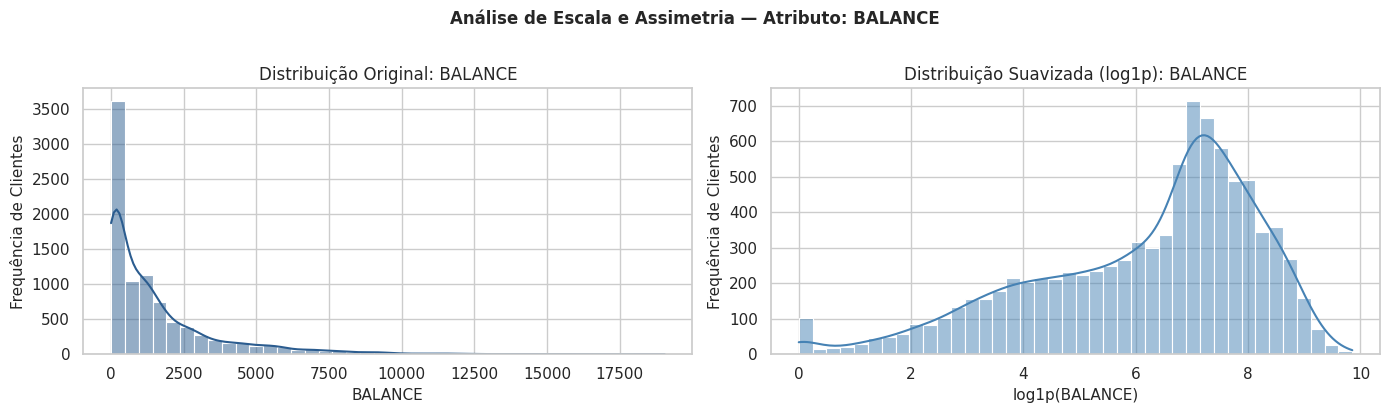

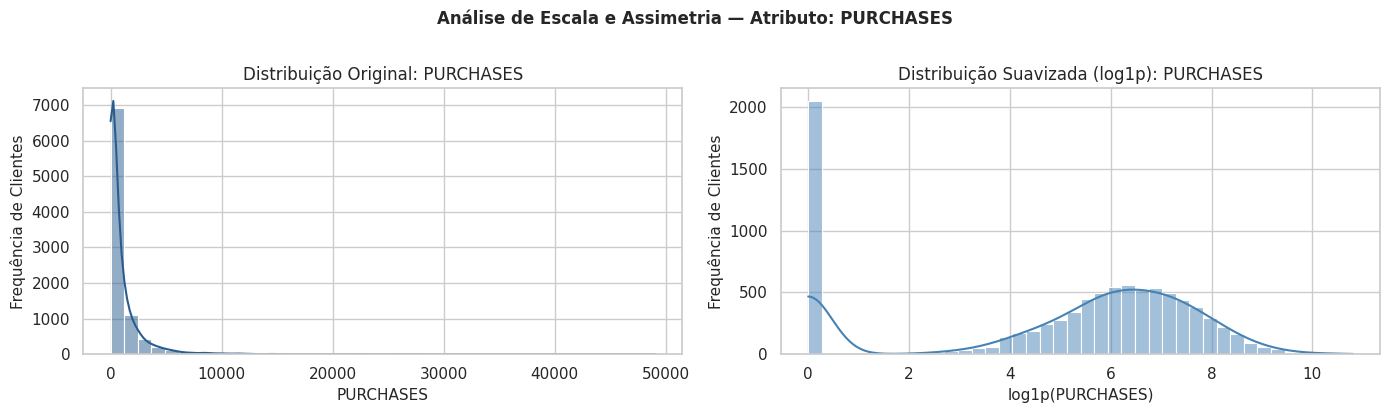

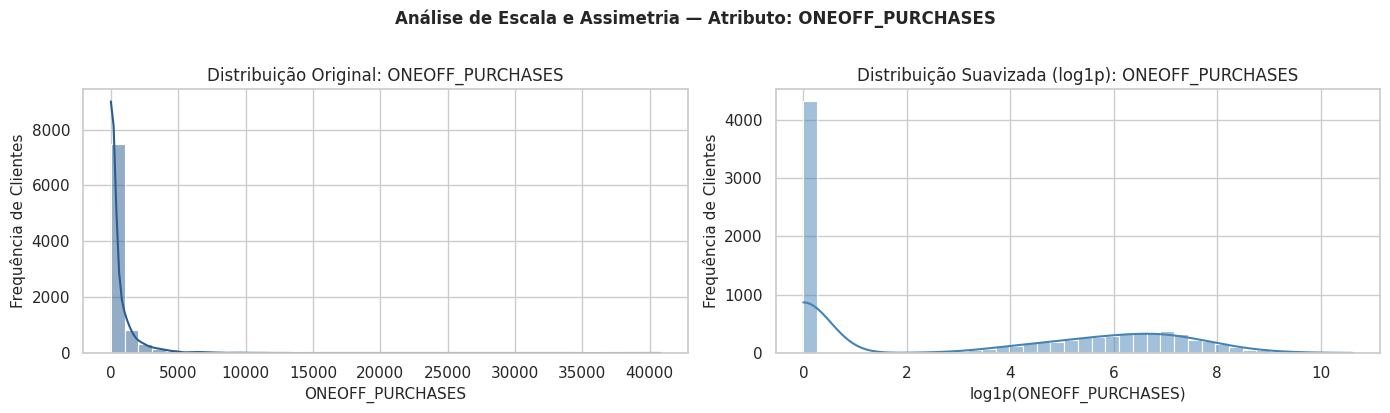

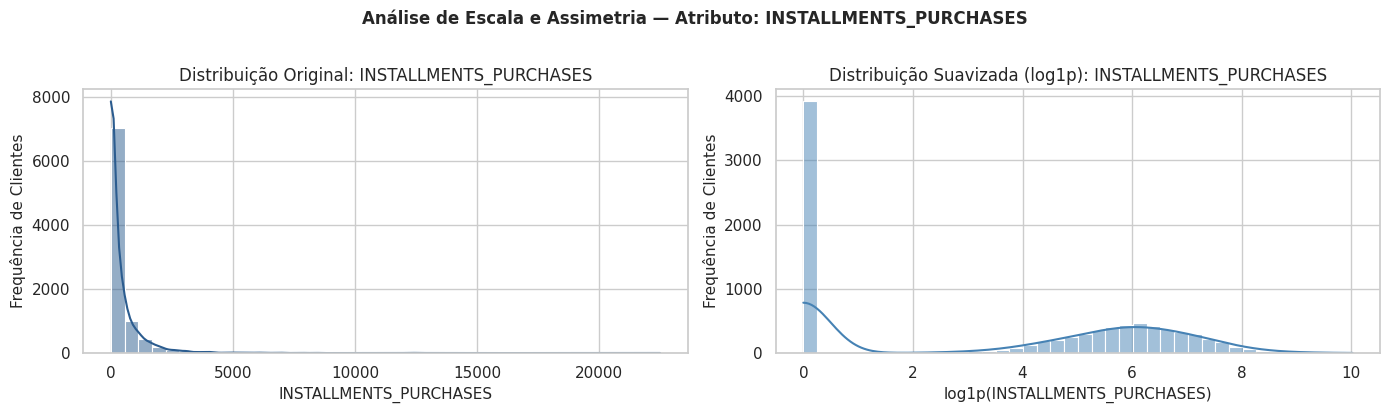

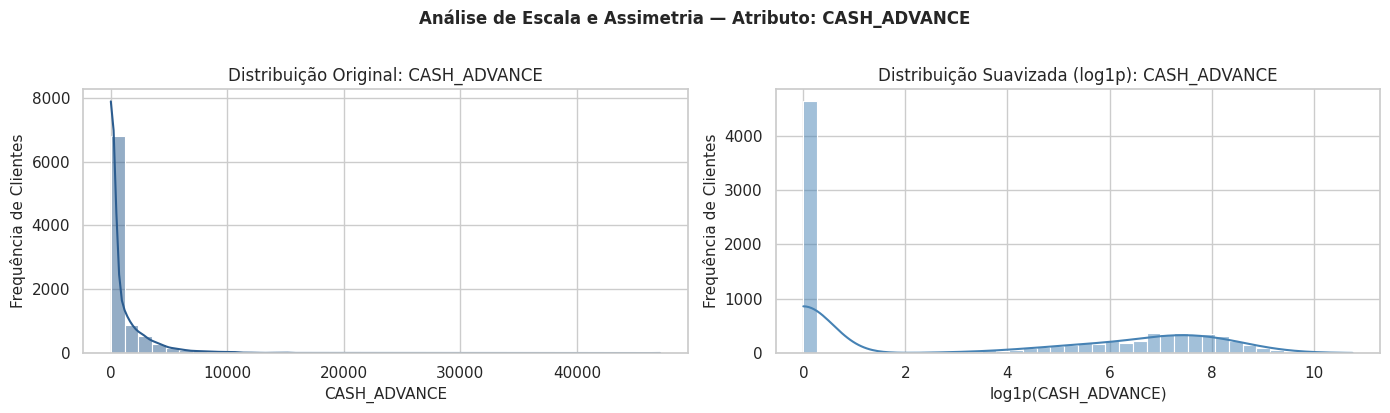

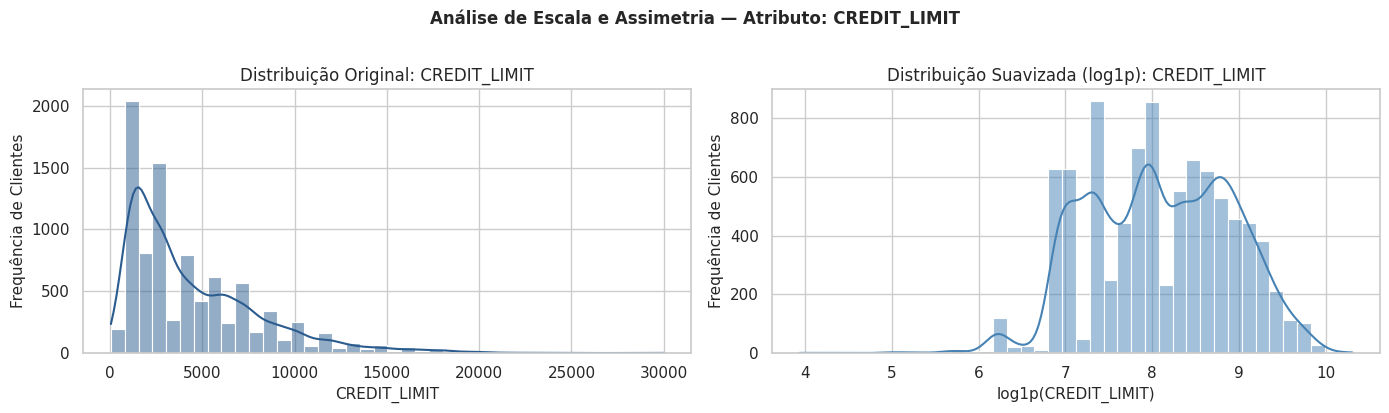

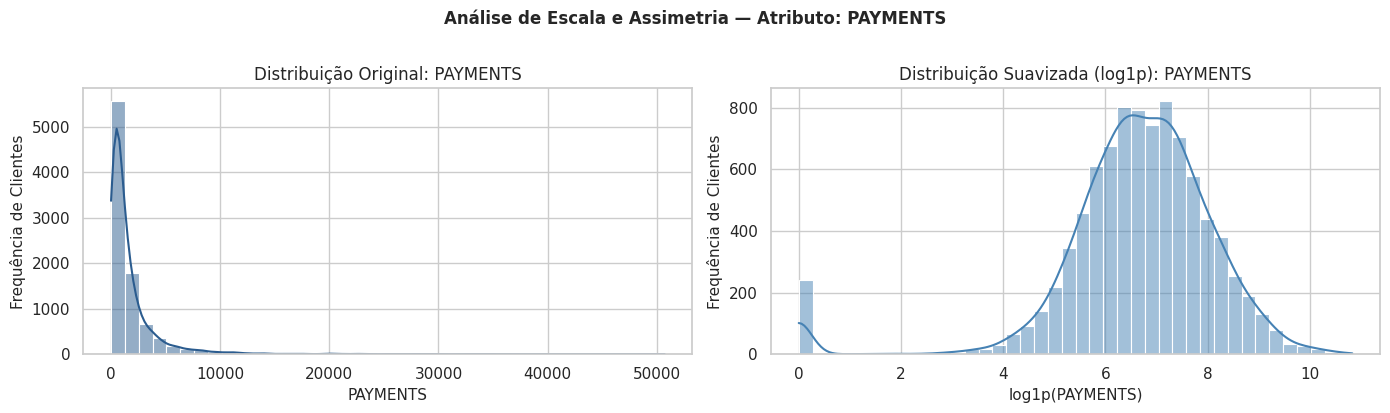

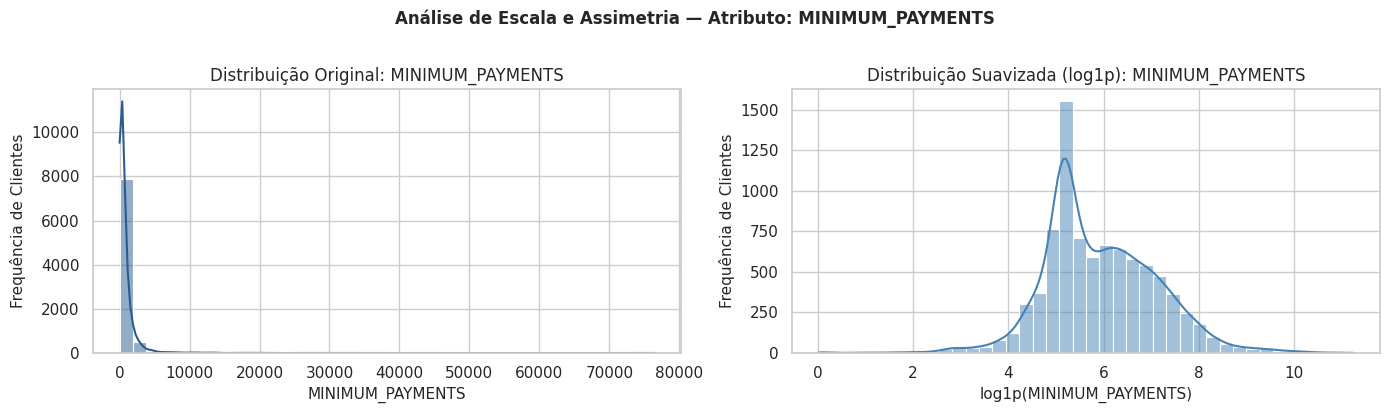


Todos os gráficos monetários foram gerados com sucesso!


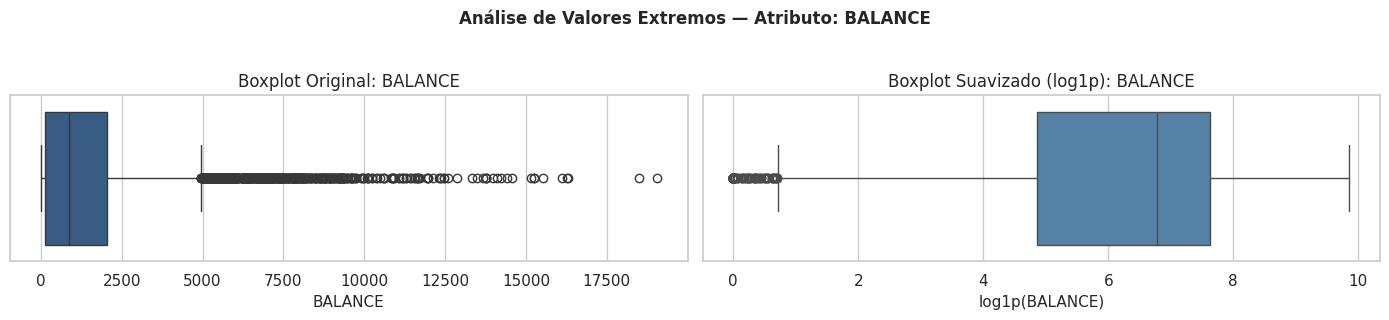

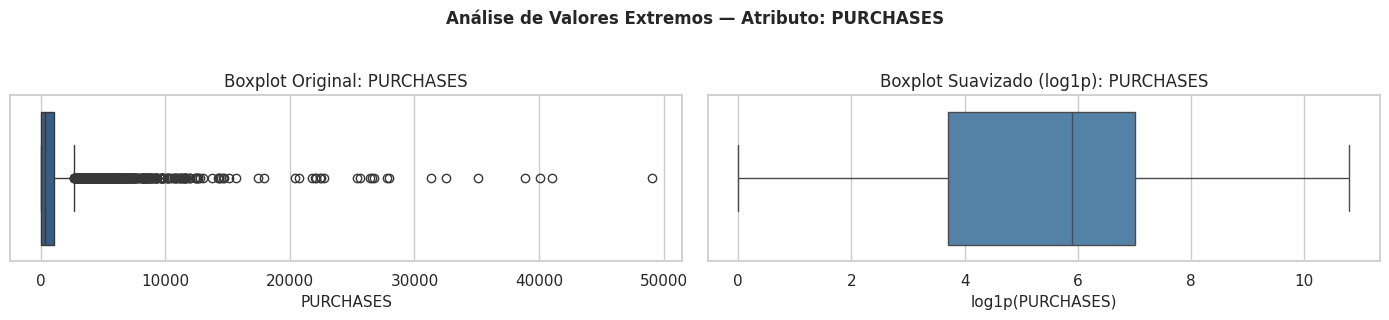

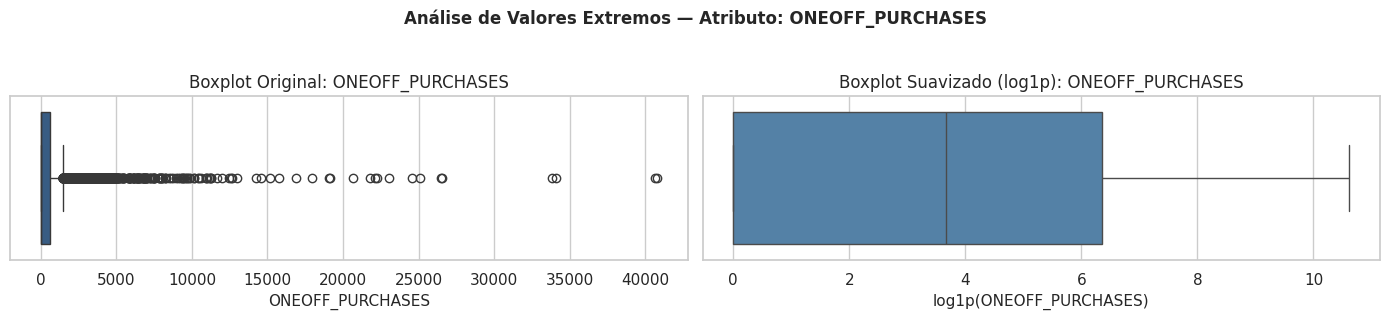

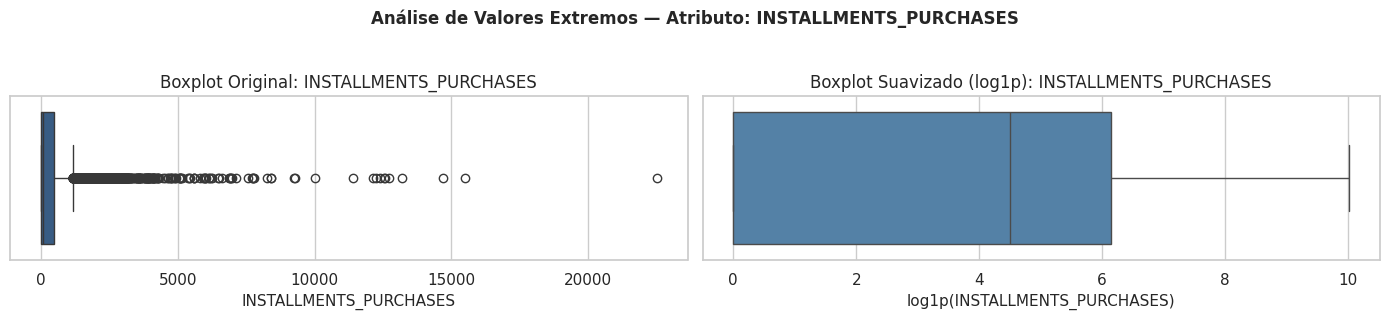

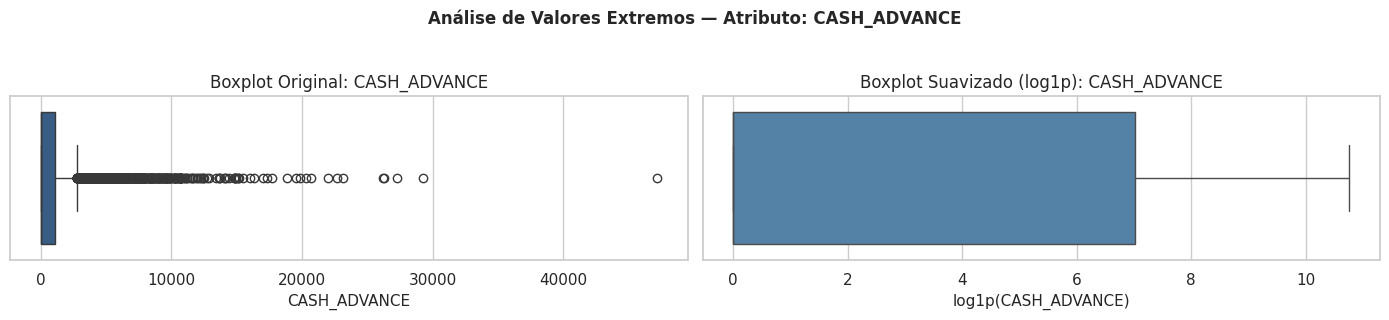

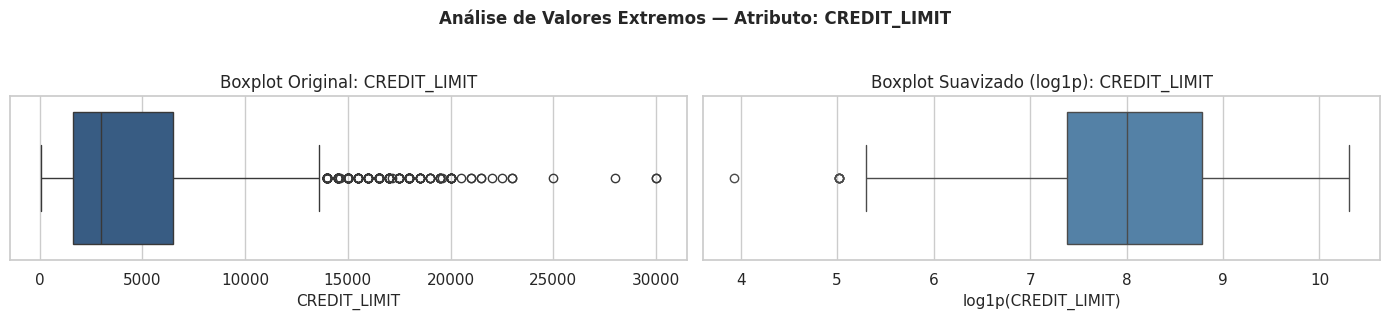

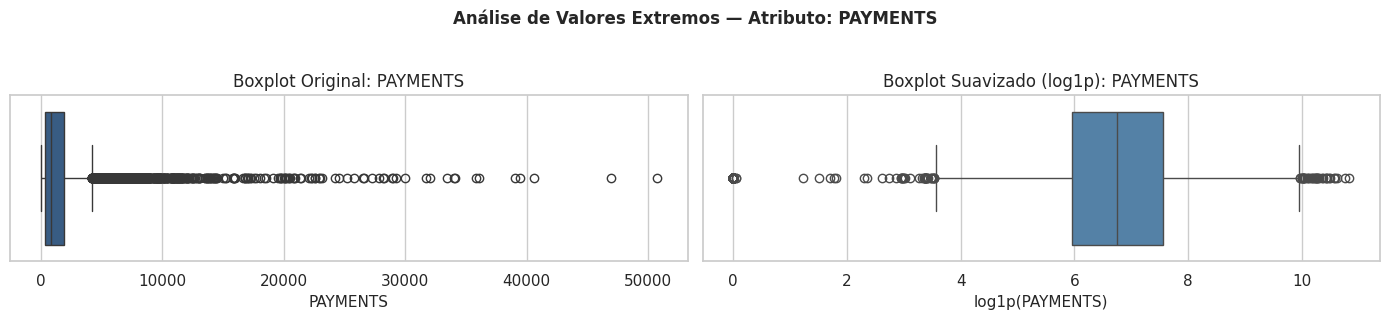

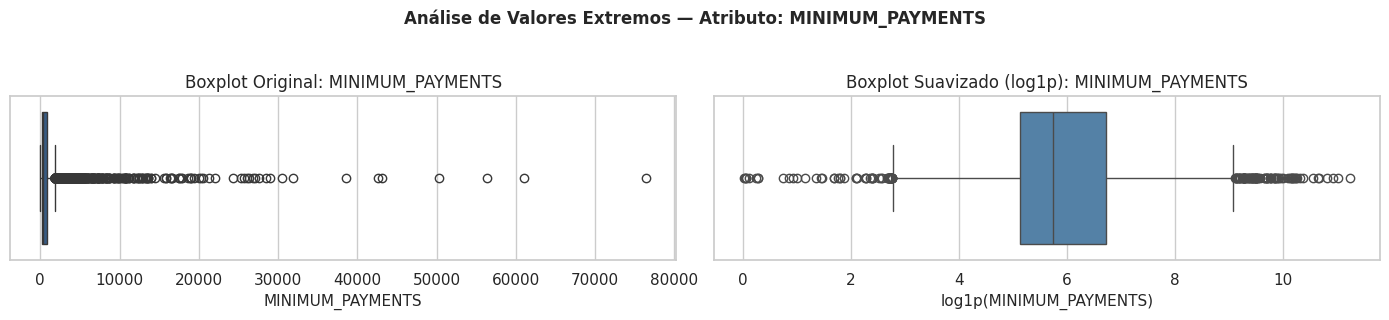

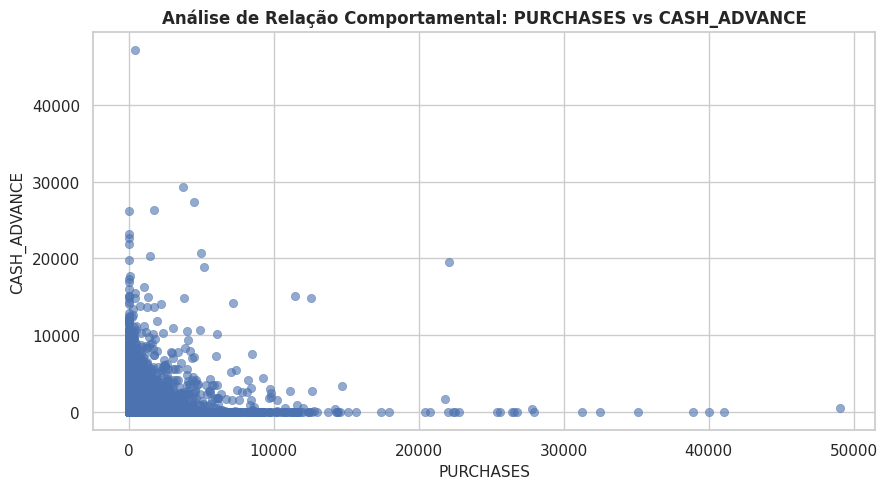

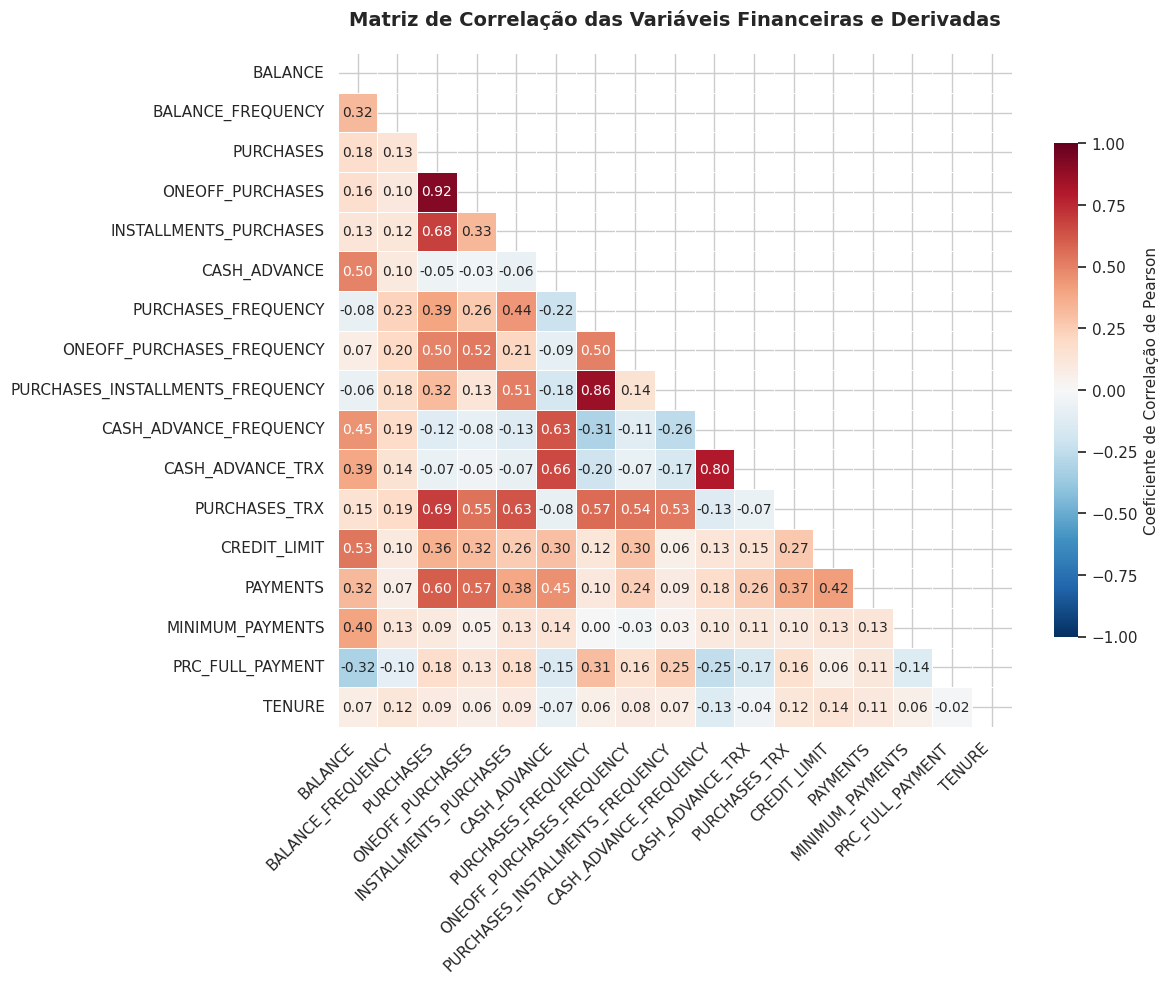

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define o estilo visual para garantir clareza e explicabilidade nos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10, "axes.labelsize": 11, "axes.titlesize": 12})

def plot_distribuicao_numerica_cc_general(df: pd.DataFrame, coluna: str) -> None:
    """
    Plota a distribuição de uma variável numérica usando KDE para avaliar a assimetria.
    Alinhado à diretriz de Justiça e Viés: ajuda a diagnosticar visualmente as 
    variáveis de cauda longa (como CASH_ADVANCE) que representam perfis vulneráveis.
    """
    if coluna not in df.columns:
        print(f"A coluna '{coluna}' não está presente no DataFrame.")
        return
        
    dados_validos = df[coluna].dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Gráfico 1: Escala Original
    sns.histplot(dados_validos, bins=40, kde=True, ax=axes[0], color="#2b5c8f")
    axes[0].set_title(f"Distribuição Original: {coluna}")
    axes[0].set_xlabel(coluna)
    axes[0].set_ylabel("Frequência de Clientes")
    
    # Gráfico 2: Escala Logarítmica (Simulando o efeito do log1p do pipeline)
    sns.histplot(np.log1p(dados_validos), bins=40, kde=True, ax=axes[1], color="#4682b4")
    axes[1].set_title(f"Distribuição Suavizada (log1p): {coluna}")
    axes[1].set_xlabel(f"log1p({coluna})")
    axes[1].set_ylabel("Frequência de Clientes")
    
    plt.suptitle(f"Análise de Escala e Assimetria — Atributo: {coluna}", y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_dispersao_comportamental(df: pd.DataFrame, x_col: str, y_col: str, hue_col: str = None) -> None:
    """
    Plota um gráfico de dispersão para avaliar a relação entre duas variáveis reais de negócio.
    Alinhado à Explicabilidade: foca no comportamento financeiro observado 
    (ex: Saques vs Compras) ao invés de usar projeções matemáticas abstratas.
    """
    plt.figure(figsize=(9, 5))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue_col, palette="viridis", alpha=0.6, edgecolor=None)
    plt.title(f"Análise de Relação Comportamental: {x_col} vs {y_col}", fontweight="bold")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    if hue_col:
        plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_matriz_correlacao_cc_general(df: pd.DataFrame) -> None:
    """
    Gera um mapa de calor com coeficientes de correlação de Pearson para variáveis numéricas.
    Alinhado à Explicabilidade: revela redundâncias (como PURCHASES e ONEOFF_PURCHASES)
    e interdependências que afetam o cálculo da distância Euclidiana no K-Means.
    """
    # Filtra apenas colunas numéricas relevantes (ignora ID se houver)
    numericas = df.select_dtypes(include=[np.number])
    if "CUST_ID" in numericas.columns:
        numericas = numericas.drop(columns=["CUST_ID"])
        
    if numericas.shape[1] < 2:
        print("Não há variáveis numéricas suficientes para calcular a matriz de correlação.")
        return

    corr = numericas.corr()
    
    # Cria uma máscara para ocultar o triângulo superior (evita poluição visual)
    mascara = np.triu(np.ones_like(corr, dtype=bool))
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr, 
        mask=mascara,
        cmap="RdBu_r", 
        vmax=1.0, 
        vmin=-1.0, 
        center=0,
        annot=True, 
        fmt=".2f", 
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .7, "label": "Coeficiente de Correlação de Pearson"}
    )
    plt.title("Matriz de Correlação das Variáveis Financeiras e Derivadas", fontsize=14, fontweight="bold", pad=20)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Lista com todas as variáveis puramente monetárias do dataset CC GENERAL
colunas_monetarias = [
    "BALANCE", 
    "PURCHASES", 
    "ONEOFF_PURCHASES", 
    "INSTALLMENTS_PURCHASES", 
    "CASH_ADVANCE", 
    "CREDIT_LIMIT", 
    "PAYMENTS", 
    "MINIMUM_PAYMENTS"
]

print("Iniciando a geração dos gráficos para variáveis monetárias...\n")

# 1. Varre cada coluna gerando o diagnóstico visual de assimetria e o efeito do log1p
for coluna in colunas_monetarias:
    if coluna in df.columns:
        plot_distribuicao_numerica_cc_general(df, coluna)
    else:
        print(f"Aviso: A coluna {coluna} não foi encontrada no DataFrame.")

print("\nTodos os gráficos monetários foram gerados com sucesso!")

# 2. Varre cada coluna monetária gerando o comparativo do Boxplot
for coluna in colunas_monetarias:
    if coluna in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 3))
        
        # Boxplot 1: Escala Original
        sns.boxplot(x=df[coluna].dropna(), ax=axes[0], color="#2b5c8f")
        axes[0].set_title(f"Boxplot Original: {coluna}")
        axes[0].set_xlabel(coluna)
        
        # Boxplot 2: Escala Transformada (log1p)
        sns.boxplot(x=np.log1p(df[coluna].dropna()), ax=axes[1], color="#4682b4")
        axes[1].set_title(f"Boxplot Suavizado (log1p): {coluna}")
        axes[1].set_xlabel(f"log1p({coluna})")
        
        plt.suptitle(f"Análise de Valores Extremos — Atributo: {coluna}", y=1.05, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Aviso: A coluna {coluna} não foi encontrada no DataFrame.")

# 2. Avaliar o comportamento de uso de saques contra volume de compras:
plot_dispersao_comportamental(df, x_col="PURCHASES", y_col="CASH_ADVANCE")

# 3. Diagnóstico completo de colinearidade antes da modelagem:
plot_matriz_correlacao_cc_general(df)

## 2.2 Análise visual e principais insights

A análise visual dos dados revela uma assimetria positiva (*right-skewed*) extrema em todas as variáveis monetárias brutas, com especial destaque para `CASH_ADVANCE`, `BALANCE`, `PURCHASES` e `MINIMUM_PAYMENTS`. Nos gráficos de distribuição original, a massa principal de dados fica severamente concentrada próxima ao zero, enquanto uma cauda longa se estende de forma acentuada à direita. Este comportamento geométrico valida empiricamente a rejeição do uso do `StandardScaler`, uma vez que o cálculo da distância euclidiana seria severamente distorcido pelas variáveis monetárias de maior magnitude, mascarando os padrões dos demais clientes. Em contrapartida, os gráficos comparativos provam que a aplicação da transformação `log1p` reposiciona os dados em distribuições aproximadamente multimodais ou suavizadas, o que permite ao algoritmo $K\text{-Means}$ identificar nuances comportamentais tanto em clientes de baixo volume transacional quanto naqueles de alto volume.

Essa assimetria é acompanhada por uma quantidade massiva de valores extremos, confirmados pelos boxplots das variáveis brutas que exibem pontos muito além dos limites teóricos do Intervalo Interquartil ($IQR$), especialmente em `CREDIT_LIMIT` e `CASH_ADVANCE`. A inspeção visual reafirma que esses valores discrepantes não decorrem de erros de digitação ou ruídos operacionais do sistema, mas sim de comportamentos financeiros extremos e legítimos de mercado, caracterizando desde clientes corporativos com tetos de crédito altíssimos até indivíduos em forte estresse financeiro recorrendo ao limite máximo de saque. Eliminá-los da modelagem mascararia justamente as carteiras de maior risco e as de maior faturamento da instituição, violando a diretriz de *Justiça e Viés*. Por isso, o uso do `RobustScaler` em conjunto com o `log1p` garante a retenção inclusiva desses dados e protege o posicionamento dos centroides contra distorções arbitrárias.

Sob a ótica de variáveis categóricas ou desbalanceamento de classes, a estrutura atual do dataset mitiga riscos comuns de viés. A presença de categorias raras não se aplica a este cenário pois, após a remoção do identificador de alta cardinalidade `CUST_ID`, o dataset passou a ser composto por atributos 100% numéricos, eliminando a ocorrência de níveis esparsos. Da mesma forma, por se tratar de uma tarefa de mineração de dados não supervisionada voltada ao agrupamento, não existe uma variável-alvo pré-definida (*ground truth*), o que torna o conceito tradicional de desbalanceamento de classes inaplicável na entrada. Uma eventual disparidade na distribuição populacional será avaliada adiante e de forma interna, monitorando se o modelo final gerará partições excessivamente pequenas (como clusters com menos de 1% da base), o que comprometeria a interpretabilidade e a utilidade prática das personas desenhadas para o negócio.

Por fim, o cruzamento de atributos expõe relações visuais altamente relevantes e padrões comportamentais nítidos. A matriz de dispersão cruzada revela uma estrutura em formato de "L" ao contrastar `PURCHASES` com `CASH_ADVANCE`, dividindo a base em duas direções ortogonais: um grupo que se estende puramente sobre o eixo horizontal, composto por clientes que utilizam o cartão estritamente para consumo e mantêm saques zerados, e outro que se projeta verticalmente, representando usuários que adotam o produto como linha de microcrédito emergencial via saque, registrando volume de compras quase nulo. Adicionalmente, observa-se uma forte relação linear e densa entre `PURCHASES` e `ONEOFF_PURCHASES`, bem como entre `BALANCE` e `MINIMUM_PAYMENTS`. Como o $K\text{-Means}$ assume independência geométrica entre os atributos, o mapeamento visual dessas redundâncias e colinearidades justifica e chancela a decisão do grupo de construir variáveis derivadas de proporção, como `RAZAO_SAQUE_COMPRA` e `UTILIZACAO_LIMITE`, resumindo as dinâmicas financeiras de forma normalizada e garantindo a *Explicabilidade* do modelo.

In [9]:
# Verificação simples de duplicatas, nulos e possíveis identificadores

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    if df is None:
        print("Dataset não carregado.")
        return {}

    diagnostico = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": []
    }

    for col in df.columns:
        proporcao_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if proporcao_unicos > 0.95:
            diagnostico["colunas_possiveis_ids"].append(col)

    return diagnostico

# Exemplo de uso:
diagnostico = diagnostico_qualidade(df)
print(json.dumps(diagnostico, indent=2, ensure_ascii=False))

{
  "n_linhas": 8950,
  "n_colunas": 18,
  "n_duplicatas_exatas": 0,
  "colunas_com_nulos": [
    "CREDIT_LIMIT",
    "MINIMUM_PAYMENTS"
  ],
  "colunas_possiveis_ids": [
    "CUST_ID",
    "BALANCE",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"
  ]
}


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
|---|---|---|---|
| Valores ausentes em MINIMUM_PAYMENTS | 313 valores nulos encontrados (3,50% do total de instâncias). | Imputar os valores ausentes utilizando a mediana global do atributo. | A exclusão dos registros geraria viés de sobrevivência, removendo clientes recém-nascidos na base ou sem faturas fechadas. Como a distribuição é fortemente assimétrica, a mediana é estatisticamente mais robusta que a média, pois não é distorcida por valores extremos, preservando a fidelidade dos dados. |
| Valores ausentes em CREDIT_LIMIT | 1 único valor nulo encontrado (0,01% do total de instâncias). | Imputar o único valor ausente utilizando a mediana global do atributo. | Por se tratar de um único registro em uma base de 8.950 linhas, a exclusão da linha seria aceitável, mas a imputação pela mediana foi adotada para garantir a integridade e consistência analítica do pipeline automatizado, sem causar qualquer impacto estatístico nos centroides. |
| Duplicatas | O mapeamento de linhas redundantes retornou exatamente 0 duplicatas exatas. | Manter a base intacta, sem necessidade de ações de desduplicação. | A ausência de duplicatas confirma que cada linha descreve a assinatura de uso exclusiva e individual de uma conta ativa, garantindo a legitimidade volumétrica do dataset para o algoritmo de agrupamento. |
| Outliers | Boxplots e o teste IQR revelaram centenas de pontos extremos à direita em CASH_ADVANCE, BALANCE e CREDIT_LIMIT. | Reter todos os registros e tratá-los através de transformações matemáticas (log1p + RobustScaler). | Sob a ótica de Justiça e Viés, os outliers representam comportamentos reais de mercado (clientes corporativos ou de alta vulnerabilidade). Eliminá-los excluiria os perfis mais críticos do negócio. O pipeline com log e escala robusta comprime as distâncias geométricas sem eliminar a informação. |
| Alta cardinalidade | A coluna CUST_ID apresenta 8.950 valores textuais distintos. | Remover o atributo antes do treinamento do modelo. | Atributos com cardinalidade igual ao número total de linhas funcionam como chaves primárias. Eles adicionam ruído puramente aleatório ao cálculo de distância euclidiana do K-Means e prejudicam o desempenho computacional, sem agregar valor preditivo. |
| Atributos identificadores | CUST_ID mapeado como identificador explícito. BALANCE, PAYMENTS e MINIMUM_PAYMENTS foram apontados como falsos-positivos de IDs pelo script automático devido à precisão de suas casas decimais contínuas. | Remover apenas o identificador textual CUST_ID. Manter as demais colunas monetárias como features. | Variáveis financeiras contínuas de alta precisão decimal podem parecer IDs para algoritmos simples devido ao grande número de valores únicos. No entanto, elas carregam a variância e a magnitude dos saldos dos clientes, sendo fundamentais para a tarefa de segmentação comportamental. |
| Atributos sensíveis | Não há dados sociodemográficos diretos. Contudo, variáveis como CASH_ADVANCE e MINIMUM_PAYMENTS agem como proxies de vulnerabilidade. | Manter no pipeline, mas aplicar uma política de rótulos estritamente neutros na interpretação. | Omitir essas variáveis impediria a instituição de identificar e proteger clientes em estresse financeiro severo (ferindo a Justiça). A permanência desses atributos garante a Explicabilidade das reais pressões econômicas sofridas pelos usuários no uso do limite. |

### Observação sobre responsabilidade

A decisão de não remover os outliers monetários e de imputar os nulos de MINIMUM_PAYMENTS pela mediana reflete o compromisso com uma modelagem inclusiva. Se tivéssemos seguido a abordagem convencional de limpeza (exclusão cega de registros fora dos limites do IQR), estaríamos apagando do mapa algorítmico justamente os clientes mais propensos ao superendividamento (usuários de saques emergenciais frequentes). Tratar esses dados via log1p e RobustScaler garante que o modelo seja matematicamente estável, sem recorrer à exclusão de grupos vulneráveis.

Ademais, a rejeição da remoção de variáveis com alta precisão decimal (que foram incorretamente sugeridas como "identificadores" em varreduras automáticas de cardinalidade, como BALANCE e PAYMENTS) foi essencial para manter o modelo explicável. Sem essas variáveis contínuas, o algoritmo perderia a capacidade de diferenciar a volumetria financeira real das transações. Mantê-las assegura que o mapeamento final das personas faça sentido direto para o negócio, permitindo que os gerentes compreendam os agrupamentos com base em faturas e saldos devedores reais, e não em índices puramente abstratos.

In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

def preparar_dados_final(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, RobustScaler]:
    """
    Pipeline definitivo de preparação de dados para a Fase 3 (Dataset CC GENERAL).
    Alinhado às diretrizes de Explicabilidade e Justiça e Viés.
    
    Retorna:
        df_original_tratado: Dados com nulos imputados e variáveis derivadas, na escala original (para interpretação).
        df_escalado: Dados prontos para o K-Means (após log1p e RobustScaler).
        scaler: O objeto RobustScaler ajustado (para fins de auditoria e reaplicação).
    """
    if df is None:
        raise ValueError("O DataFrame de entrada não foi carregado corretamente.")

    # Trabalha sobre uma cópia para evitar side-effects nos dados brutos
    df_prep = df.copy()

    # 1. Remoção de Identificadores (Privacidade e Minimização de Dados)
    colunas_remover = ["CUST_ID"]
    colunas_remover = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_remover)

    # 2. Tratamento de Valores Ausentes via Mediana (Mitigação de Viés de Sobrevivência)
    # MINIMUM_PAYMENTS (313 nulos) e CREDIT_LIMIT (1 nulo) imputados com segurança estatística
    for col in df_prep.select_dtypes(include=np.number).columns:
        if df_prep[col].isna().any():
            mediana_treino = df_prep[col].median()
            df_prep[col] = df_prep[col].fillna(mediana_treino)

    # 3. Engenharia de Atributos: Criação das Variáveis Derivadas de Proporção Comportamental
    # Substituímos zeros por NaN antes da divisão para evitar indeterminações matemáticas (Infinito)
    
    # Razão 1: Utilização do Limite Concedido
    df_prep["UTILIZACAO_LIMITE"] = df_prep["BALANCE"] / df_prep["CREDIT_LIMIT"].replace(0, np.nan)
    
    # Razão 2: Capacidade de Amortização da Dívida em Relação ao Mínimo Exigido
    df_prep["RAZAO_PAGAMENTO_MINIMO"] = df_prep["PAYMENTS"] / df_prep["MINIMUM_PAYMENTS"].replace(0, np.nan)
    
    # Razão 3: Intensidade de Uso Emergencial (Saque) contra Uso Convencional (Consumo)
    # Somamos 1 ao denominador para mitigar divisões por zero sem distorcer a proporção de quem zerou compras
    df_prep["RAZAO_SAQUE_COMPRA"] = df_prep["CASH_ADVANCE"] / (df_prep["PURCHASES"] + 1)

    # 4. Tratamento de Indeterminações e Suavização de Outliers Extremos nas Razões
    # Divisões que resultaram em NaN ou Infinito devido a saldos zerados são corrigidas para 0.0
    colunas_derivadas = ["UTILIZACAO_LIMITE", "RAZAO_PAGAMENTO_MINIMO", "RAZAO_SAQUE_COMPRA"]
    for col in colunas_derivadas:
        df_prep[col] = df_prep[col].replace([np.inf, -np.inf], np.nan).fillna(0.0)
        
        # Corte controlado no percentil 99% para evitar que distorções extremas gerem subclusters isolados artificiais
        limite_p99 = df_prep[col].quantile(0.99)
        df_prep[col] = np.where(df_prep[col] > limite_p99, limite_p99, df_prep[col])

    # Salvaguarda para a Explicabilidade: Mantemos uma cópia tratada na escala real (monetária/original)
    df_original_tratado = df_prep.copy()

    # 5. Transformação de Escala e Compressão Estatística (Trilha B - IA Responsável)
    # Seleciona todas as colunas numéricas atuais para o processo de transformação
    colunas_numericas = df_prep.select_dtypes(include=np.number).columns
    
    # Passo A: Aplicação do log1p para atenuar a cauda longa de assimetria monetária
    for col in colunas_numericas:
        df_prep[col] = np.log1p(df_prep[col])

    # Passo B: Aplicação do RobustScaler para blindar as distâncias contra a variabilidade residual dos quartis
    scaler = RobustScaler(with_centering=True, with_scaling=True)
    dados_escalados = scaler.fit_transform(df_prep[colunas_numericas])
    
    # Reconstrói o DataFrame escalado mantendo os índices e os nomes das colunas originais
    df_escalado = pd.DataFrame(dados_escalados, columns=colunas_numericas, index=df_prep.index)

    # Auditoria de saída do pipeline
    print("-" * 60)
    print("PIPELINE DE PREPARAÇÃO CONCLUÍDO COM SUCESSO")
    print("-" * 60)
    print(f"Dimensões finais do dataset de treino: {df_escalado.shape[0]} linhas × {df_escalado.shape[1]} colunas")
    print(f"Atributos incluídos: {list(df_escalado.columns)}")
    print(f"Total de valores nulos residuais na base de modelagem: {df_escalado.isna().sum().sum()}")
    print("-" * 60)

    return df_original_tratado, df_escalado, scaler

df_interpretar, df_modelar, scaler_ajustado = preparar_dados_final(df)
display(df_modelar.head())

------------------------------------------------------------
PIPELINE DE PREPARAÇÃO CONCLUÍDO COM SUCESSO
------------------------------------------------------------
Dimensões finais do dataset de treino: 8950 linhas × 20 colunas
Atributos incluídos: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'UTILIZACAO_LIMITE', 'RAZAO_PAGAMENTO_MINIMO', 'RAZAO_SAQUE_COMPRA']
Total de valores nulos residuais na base de modelagem: 0
------------------------------------------------------------


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,UTILIZACAO_LIMITE,RAZAO_PAGAMENTO_MINIMO,RAZAO_SAQUE_COMPRA
0,-1.098374,-1.667474,-0.400154,-0.576007,0.011167,0.000000,-0.440481,-0.305081,-0.132428,0.000000,0.000000,-0.446395,-0.783504,-0.901767,-0.525916,0.000000,0.0,-0.448508,-0.164646,0.000000
1,0.469421,-0.813879,-1.780990,-0.576007,-0.731443,1.250048,-0.710662,-0.305081,-0.275459,1.111990,1.000000,-0.946395,0.604504,0.978658,0.807362,1.502798,0.0,0.224415,0.356132,2.918483
2,0.379228,0.000000,0.229522,0.469827,-0.731443,0.000000,0.504223,2.336846,-0.275459,0.000000,0.000000,0.220964,0.653731,-0.199976,0.456190,0.000000,0.0,0.045461,-0.322306,0.000000
3,0.233419,-3.510781,0.429440,0.573821,-0.731443,0.759885,-0.570371,0.000000,-0.275459,0.398875,0.430677,-0.630930,0.653731,-4.223218,0.000000,0.000000,0.0,-0.127502,-0.850422,0.042779
4,-0.023783,0.000000,-0.924648,-0.130552,-0.731443,0.000000,-0.570371,0.000000,-0.275459,0.000000,0.000000,-0.630930,-0.653517,-0.145917,-0.159225,0.000000,0.0,0.510118,0.167026,0.000000


## 2.4 Justificativa da preparação final

O pipeline de preparação final dos dados foi desenhado para converter um conjunto de registros financeiros brutos, altamente assimétricos e colineares, numa estrutura geométrica perfeitamente equilibrada e adequada para o algoritmo de agrupamento $K\text{-Means}$. Cada etapa deste processo foi auditada e fundamentada sob critérios estatísticos e éticos.

A coluna `CUST_ID` foi a única formalmente removida do ecossistema de modelagem, pois trata-se de um identificador alfanumérico textual de cardinalidade máxima, cuja exclusão se justifica pela diretriz de Privacidade e Minimização de Dados para mitigar riscos de reidentificação por ligação externa. Do ponto de vista da estabilidade geométrica, um ID não carrega variância comportamental útil e a sua permanência adicionaria ruído aleatório ao cálculo da distância euclidiana. Nenhum outro atributo original foi descartado, rejeitando-se varreduras automatizadas que sugeriram apagar atributos contínuos de alta precisão decimal por confundi-los erroneamente com identificadores.

Os valores ausentes foram identificados de forma restrita em `MINIMUM_PAYMENTS` e `CREDIT_LIMIT`, e o grupo adotou a estratégia de imputação estatística pela mediana global de cada variável. Esta decisão eliminou a necessidade de exclusão cega de linhas, impedindo a introdução de um viés de sobrevivência, visto que os nulos em pagamentos mínimos representam perfis legítimos de contas recém-criadas ou inativas que ainda não haviam fechado o primeiro ciclo de fatura. Como as distribuições originais são severamente assimétricas, a média seria deslocada artificialmente para cima por utilizadores de altíssima renda, fazendo com que a mediana se consolidasse como a medida de posição mais robusta para preservar o centro de gravidade original dos dados brutos.

O grupo também introduziu três novas variáveis de proporção financeira para capturar padrões latentes de comportamento de forma normalizada, superando as redundâncias e colinearidades monetárias mapeadas na exploração visual. Foram criadas as métricas de `UTILIZACAO_LIMITE`, que mede o comprometimento do crédito concedido, `RAZAO_PAGAMENTO_MINIMO`, que avalia se o cliente está preso na engrenagem do crédito rotativo ou se possui capacidade de amortização substancial, e `RAZAO_SAQUE_COMPRA`, que contrasta diretamente o uso do cartão como socorro financeiro emergencial contra o uso tradicional como meio de consumo. Para evitar erros de compilação ou indeterminações matemáticas, aplicou-se um tratamento rigoroso que substituiu divisões por zero e infinitos por valores zerados. Adicionalmente, aplicou-se um corte controlado no percentil 99% sobre essas razões derivadas para impedir que clientes com proporções descomunais gerassem subclusters artificiais e isolados, protegendo a coesão populacional dos futuros agrupamentos.

Finalmente, para preparar os dados para a tarefa específica do $K\text{-Means}$ — algoritmo que baseia-se na distância euclidiana e pressupõe que os atributos possuam distribuições simétricas e na mesma escala geométrica —, aplicou-se um pipeline sequencial em duas etapas. Primeiro, utilizou-se a transformação logarítmica (`log1p`) de forma generalizada em todas as variáveis numéricas, pois o operador comprimiu a cauda longa de assimetria positiva sem quebrar as instâncias zeradas. Segundo, aplicou-se o escalonamento robusto (`RobustScaler`), que centraliza e dimensiona os dados com base na mediana e no intervalo interquartil (IQR), em detrimento do `StandardScaler`. Esta escolha garantiu que as variáveis de montante monetário transformadas passassem a partilhar do mesmo peso geométrico que as variáveis de frequência, blindando as distâncias contra a variabilidade residual de outliers legítimos.

A consolidação deste pipeline reflete uma árvore de decisão clara que separa as contribuições de cada ambiente e as intervenções críticas feitas pelo grupo. Da Trilha A (baseline) herdou-se apenas a diretriz elementar de remover a coluna identificadora e a noção inicial de que a base precisava passar por uma padronização de escala. A Trilha B (guiada) forneceu o direcionamento técnico central para lidar com a vulnerabilidade e assimetria financeira, trazendo a justificativa ética para a imputação de nulos pela mediana e propondo a substituição do escalonador tradicional pelo combo de transformação logarítmica com padronização por quartis.

O grupo, por sua vez, contribuiu de forma independente com a formulação matemática exata e a blindagem algorítmica das três variáveis derivadas de razão, bem como com a estratégia de suavização no percentil 99%. Por fim, várias sugestões das LLMs foram corrigidas ou descartadas pelo grupo para salvaguardar os critérios de avaliação: barrou-se a recomendação da Trilha A de excluir outliers via filtro IQR por entender que estes representam comportamentos reais de mercado; corrigiu-se a grafia incorreta do atributo de pagamento integral presente em ambas as trilhas de `PR_FULL_PAYMENT` para `PRC_FULL_PAYMENT`; e descartou-se a indicação da Trilha B de interpretar os perfis dos clientes diretamente sobre as componentes abstratas do PCA, rebaixando a técnica a um suporte visual e garantindo a Explicabilidade do modelo ao ancorar o diagnóstico das personas nas variáveis reais de negócio.

In [11]:
from typing import Tuple, Optional
import pandas as pd

def preparar_matriz_modelagem_clustering(df_preparado: pd.DataFrame) -> Tuple[pd.DataFrame, Optional[None]]:
    """
    Prepara a matriz definitiva X para a tarefa específica de Agrupamento (Clustering).
    Alinhada às diretrizes de Explicabilidade e Robustez da Fase 3.
    
    Como a tarefa é não supervisionada, o vetor de alvo (y) é retornado como None.
    A função garante que nenhuma codificação redundante (como One-Hot Encoding) 
    seja aplicada, já que a base consolidada é 100% numérica e contínua.
    """
    if df_preparado is None:
        raise ValueError("O DataFrame de entrada está vazio ou não foi carregado.")

    # Cria uma cópia de segurança para isolar a matriz de treino
    X = df_preparado.copy()

    # Por definição metodológica de clustering não supervisionado, não existe variável-alvo
    y = None

    # Auditoria de consistência matemática para o K-Means
    print("-" * 60)
    print("MATRIZ DE MODELAGEM PRONTA PARA O K-MEANS")
    print("-" * 60)
    print(f"Dimensões finais da matriz X (atributos): {X.shape[0]} instâncias × {X.shape[1]} colunas")
    print(f"Tipos de dados presentes na matriz: {X.dtypes.unique()}")
    print(f"Presença de rótulo alvo (y): Não (Tarefa Não Supervisionada)")
    print("-" * 60)

    return X, y

X, y = preparar_matriz_modelagem_clustering(df_modelar)
display(X.head())

------------------------------------------------------------
MATRIZ DE MODELAGEM PRONTA PARA O K-MEANS
------------------------------------------------------------
Dimensões finais da matriz X (atributos): 8950 instâncias × 20 colunas
Tipos de dados presentes na matriz: [dtype('float64')]
Presença de rótulo alvo (y): Não (Tarefa Não Supervisionada)
------------------------------------------------------------


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,UTILIZACAO_LIMITE,RAZAO_PAGAMENTO_MINIMO,RAZAO_SAQUE_COMPRA
0,-1.098374,-1.667474,-0.400154,-0.576007,0.011167,0.000000,-0.440481,-0.305081,-0.132428,0.000000,0.000000,-0.446395,-0.783504,-0.901767,-0.525916,0.000000,0.0,-0.448508,-0.164646,0.000000
1,0.469421,-0.813879,-1.780990,-0.576007,-0.731443,1.250048,-0.710662,-0.305081,-0.275459,1.111990,1.000000,-0.946395,0.604504,0.978658,0.807362,1.502798,0.0,0.224415,0.356132,2.918483
2,0.379228,0.000000,0.229522,0.469827,-0.731443,0.000000,0.504223,2.336846,-0.275459,0.000000,0.000000,0.220964,0.653731,-0.199976,0.456190,0.000000,0.0,0.045461,-0.322306,0.000000
3,0.233419,-3.510781,0.429440,0.573821,-0.731443,0.759885,-0.570371,0.000000,-0.275459,0.398875,0.430677,-0.630930,0.653731,-4.223218,0.000000,0.000000,0.0,-0.127502,-0.850422,0.042779
4,-0.023783,0.000000,-0.924648,-0.130552,-0.731443,0.000000,-0.570371,0.000000,-0.275459,0.000000,0.000000,-0.630930,-0.653517,-0.145917,-0.159225,0.000000,0.0,0.510118,0.167026,0.000000


# 3. Modeling

Nesta seção, o grupo deve implementar a solução final.

A modelagem final deve ser resultado de uma decisão crítica, não de simples cópia da LLM.

A seção deve deixar claro:

- quais algoritmos foram testados;
- quais parâmetros foram usados;
- por que esses algoritmos foram escolhidos;
- o que foi inspirado pela baseline;
- o que foi inspirado pela trilha guiada;
- o que foi corrigido ou decidido pelo grupo;
- como a implementação se relaciona às diretrizes de IA responsável.

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline | Sugestão guiada | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| Algoritmo(s) | Usar K-Means como algoritmo principal, com apoio do método do cotovelo e Silhouette para escolher `K`. | Manter K-Means, mas com parâmetros reprodutíveis e interpretação dos grupos por variáveis originais; usar PCA apenas como apoio visual. | K-Means final com `K=4`, `init="k-means++"`, `n_init=10`, `max_iter=300` e `random_state=42`. DBSCAN foi considerado apenas como alternativa exploratória, mas não adotado como solução final. | O K-Means é compatível com o objetivo de segmentação comportamental, escala bem para 8.950 clientes e gera centroides/perfis interpretáveis. O DBSCAN é mais difícil de calibrar nesta base de alta dimensão e tende a depender fortemente de `eps`. |
| Preparação dos dados | Remover `CUST_ID`, tratar nulos e aplicar padronização, com tendência a usar `StandardScaler` e limpeza mais convencional. | Imputar nulos por mediana, aplicar `log1p`, preferir `RobustScaler` e evitar remoção automática de outliers monetários legítimos. | Remoção de `CUST_ID`; imputação por mediana em `MINIMUM_PAYMENTS` e `CREDIT_LIMIT`; criação de `UTILIZACAO_LIMITE`, `RAZAO_PAGAMENTO_MINIMO` e `RAZAO_SAQUE_COMPRA`; corte controlado no percentil 99% para razões; `log1p` + `RobustScaler`. | A solução final combina estabilidade geométrica com preservação de perfis financeiros extremos, evitando apagar clientes relevantes para a análise de vulnerabilidade. |
| Parâmetros | Testar valores de `K` e usar parâmetros padrão do K-Means com alguma menção a `k-means++`. | Fixar `random_state`, usar `k-means++`, `n_init >= 10` e `max_iter=300` para reduzir instabilidade. | Varredura de `K=2` a `K=8`; escolha final de `K=4`; `init="k-means++"`, `n_init=10`, `max_iter=300`, `random_state=42`. | A configuração garante reprodutibilidade e permite comparar alternativas antes da escolha final. A seleção de `K=4` foi guiada por métricas e por interpretabilidade de negócio. |
| Métricas | Inércia e Silhouette Score como critérios principais. | Inércia, Silhouette Score, Davies-Bouldin e análise qualitativa dos perfis. | Inércia, Silhouette, Davies-Bouldin, distribuição de clientes por cluster e medianas das variáveis originais/derivadas. | Como não há rótulo verdadeiro, métricas internas são necessárias, mas insuficientes. A decisão final precisa considerar também tamanho e legibilidade dos grupos. |
| Estratégia de avaliação | Escolher o maior Silhouette ou o ponto de cotovelo de forma mais direta. | Combinar métricas com explicação dos clusters e cautela no uso de perfis financeiros. | Comparar `K=2..8`, reconhecer que `K=3` maximiza Silhouette, mas adotar `K=4` por revelar uma persona adicional de dependência de saque emergencial. | O melhor resultado matemático puro (`K=3`) poderia diluir um perfil vulnerável. A solução final aceita pequena perda de Silhouette para ganhar explicabilidade e utilidade analítica. |
| Cuidados de IA responsável | Pouca discussão explícita; risco de usar clusters como rótulos comerciais ou de risco. | Reforça explicabilidade, neutralidade de rótulos, não exclusão de outliers e não uso punitivo dos agrupamentos. | Perfis descritos por comportamento observado, sem rótulos morais; PCA restrito à visualização; interpretação ancorada em medianas reais; outliers tratados, não removidos. | As diretrizes influenciaram decisões concretas do pipeline, dos parâmetros e da apresentação dos resultados, não apenas o texto do relatório. |

### Síntese da decisão final

A solução final implementada pelo grupo utiliza K-Means sobre uma matriz numérica preparada com foco em robustez e explicabilidade. A pipeline remove o identificador `CUST_ID`, imputa valores ausentes por mediana, cria razões financeiras interpretáveis, suaviza razões extremas no percentil 99%, aplica `log1p` para reduzir assimetria e usa `RobustScaler` para diminuir a influência residual de outliers legítimos.

A escolha final foi `K=4`. A varredura anterior mostrou que `K=3` obteve o melhor Silhouette Score aproximado (0,3260), mas a solução com quatro grupos foi mantida porque separa melhor um perfil comportamental importante: clientes com maior dependência de `CASH_ADVANCE` e maior exposição a vulnerabilidade financeira. Assim, a decisão final não maximiza apenas uma métrica interna; ela equilibra separação geométrica, tamanho dos grupos, rastreabilidade e utilidade interpretativa para o problema de negócio.

In [ ]:
# Registro simples de experimentos
# Ajuda a manter rastreabilidade de parâmetros e resultados.

experimentos = []


def registrar_experimento(nome: str, algoritmo: str, parametros: dict, metricas: dict, observacoes: str = ""):
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro


def salvar_experimentos(caminho: str = os.path.join(OUTPUT_DIR, "experimentos.json")):
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False)
    print(f"Experimentos salvos em: {caminho}")

# Exemplo:
# registrar_experimento(
#     nome="teste_inicial",
#     algoritmo="Apriori",
#     parametros={"min_support": 0.05, "min_confidence": 0.6},
#     metricas={"n_regras": 100, "tempo_segundos": 1.23},
#     observacoes="Teste preliminar."
# )

## 3.2 Modelagem para padrões frequentes

Esta seção não se aplica ao TP2, pois a tarefa definida para este trabalho é **agrupamento**. Embora a Fase 2 tenha mencionado mineração de padrões frequentes em alguns prompts, essa foi uma inconsistência de escopo identificada pelo grupo. Na Fase 3, a solução foi consolidada em torno de segmentação de clientes com K-Means.

In [ ]:
# Não aplicável ao TP2.
# A solução final deste notebook é de agrupamento com K-Means, não de padrões frequentes.

## 3.3 Modelagem para agrupamento

A modelagem final foi implementada com K-Means porque o objetivo analítico é segmentar clientes de cartão de crédito em perfis comportamentais relativamente homogêneos. O algoritmo é adequado ao tamanho da base, possui baixo custo computacional para 8.950 instâncias e permite uma interpretação direta por centroides, medianas e comparação das variáveis originais.

A avaliação não se limita ao número de clusters. Foram considerados: inércia, Silhouette Score, Davies-Bouldin, distribuição de clientes por cluster e coerência dos perfis com as variáveis financeiras de negócio. O PCA foi mantido apenas como ferramenta de visualização bidimensional, sem substituir a interpretação nas variáveis originais.

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score


def avaliar_kmeans_final(X: pd.DataFrame, intervalo_k=range(2, 9)) -> pd.DataFrame:
    """Executa a varredura final de K-Means sobre a matriz já preparada na seção 2."""
    resultados = []

    for k in intervalo_k:
        inicio = time.time()
        modelo = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            max_iter=300,
            random_state=RANDOM_STATE,
        )
        labels = modelo.fit_predict(X)
        tempo = time.time() - inicio

        resultados.append({
            "k": k,
            "inercia": modelo.inertia_,
            "silhouette": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "tempo_segundos": tempo,
        })

    return pd.DataFrame(resultados)


def treinar_kmeans_final(X: pd.DataFrame, k: int = 4) -> tuple[KMeans, np.ndarray]:
    """Treina o modelo final escolhido pelo grupo."""
    modelo = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    labels = modelo.fit_predict(X)
    return modelo, labels


def resumir_clusters(df_interpretar: pd.DataFrame, labels: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Resume tamanho e perfil mediano dos clusters na escala interpretável."""
    perfil = df_interpretar.copy()
    perfil["cluster"] = labels

    distribuicao = (
        perfil["cluster"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="quantidade_clientes")
    )
    distribuicao["percentual"] = (distribuicao["quantidade_clientes"] / len(perfil) * 100).round(2)

    colunas_perfil = [
        "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS",
        "PRC_FULL_PAYMENT", "UTILIZACAO_LIMITE", "RAZAO_PAGAMENTO_MINIMO",
        "RAZAO_SAQUE_COMPRA", "PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY",
        "PURCHASES_TRX", "CASH_ADVANCE_TRX", "TENURE",
    ]
    colunas_perfil = [col for col in colunas_perfil if col in perfil.columns]
    resumo = perfil.groupby("cluster")[colunas_perfil].median().round(2)

    return distribuicao, resumo


metricas_kmeans = avaliar_kmeans_final(X, intervalo_k=range(2, 9))
display(metricas_kmeans.round(4))

K_FINAL = 4
modelo_final, labels_final = treinar_kmeans_final(X, k=K_FINAL)
distribuicao_clusters, perfil_clusters = resumir_clusters(df_interpretar, labels_final)

display(distribuicao_clusters)
display(perfil_clusters)

registrar_experimento(
    nome="kmeans_final_k4",
    algoritmo="K-Means",
    parametros={
        "n_clusters": K_FINAL,
        "init": "k-means++",
        "n_init": 10,
        "max_iter": 300,
        "random_state": RANDOM_STATE,
        "preparacao": "mediana + razoes derivadas + p99 + log1p + RobustScaler",
    },
    metricas={
        "silhouette": float(silhouette_score(X, labels_final)),
        "davies_bouldin": float(davies_bouldin_score(X, labels_final)),
        "inercia": float(modelo_final.inertia_),
    },
    observacoes="K=4 escolhido por equilibrar interpretabilidade, tamanho dos grupos e visibilidade do perfil de dependência de saque.",
)

# Visualização auxiliar: PCA apenas para diagnóstico gráfico, não para interpretação das personas.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
componentes = pca.fit_transform(X)

df_pca = pd.DataFrame({
    "PC1": componentes[:, 0],
    "PC2": componentes[:, 1],
    "cluster": labels_final,
})

plt.figure(figsize=(8, 5))
for cluster in sorted(df_pca["cluster"].unique()):
    dados_cluster = df_pca[df_pca["cluster"] == cluster]
    plt.scatter(dados_cluster["PC1"], dados_cluster["PC2"], s=10, alpha=0.45, label=f"Cluster {cluster}")
plt.title("Projeção PCA dos clusters finais (apoio visual)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()


## 3.4 Modelagem para classificação

Esta seção não se aplica ao TP2, pois o dataset não possui variável-alvo e a tarefa definida é não supervisionada. Portanto, não foram usados treino/teste supervisionados, matriz de confusão, acurácia, precisão, recall ou F1-score.

In [ ]:
# Não aplicável ao TP2.
# A tarefa não possui variável-alvo e não utiliza classificação supervisionada.

## 3.5 Resultados da modelagem final

A modelagem final executada foi o **K-Means com `K=4`**, usando a matriz preparada na seção 2. A configuração final foi:

| Parâmetro | Valor |
|---|---|
| Algoritmo | K-Means |
| `n_clusters` | 4 |
| `init` | `k-means++` |
| `n_init` | 10 |
| `max_iter` | 300 |
| `random_state` | 42 |
| Preparação | Imputação por mediana + variáveis derivadas + corte p99 nas razões + `log1p` + `RobustScaler` |
| Interpretação | Medianas nas variáveis originais e derivadas; PCA apenas visual |

### Varredura de K

A grade de experimentos anterior avaliou `K` entre 2 e 8. Os resultados principais foram:

| K | Inércia | Silhouette | Davies-Bouldin |
|---:|---:|---:|---:|
| 2 | 170288.2583 | 0.2906 | 1.7473 |
| 3 | 139740.7263 | 0.3260 | 1.2355 |
| 4 | 117005.1507 | 0.2536 | 1.3509 |
| 5 | 105689.1864 | 0.2479 | 1.2830 |
| 6 | 95360.9117 | 0.2570 | 1.2279 |
| 7 | 86615.3309 | 0.2667 | 1.1428 |
| 8 | 81839.8290 | 0.2340 | 1.2770 |

A métrica de Silhouette indica vantagem matemática para `K=3`, com valor aproximado de **0,3260**. No entanto, a solução final com `K=4` foi escolhida porque apresentou um equilíbrio mais útil para o problema de negócio: manteve clusters com tamanhos razoáveis e separou um perfil adicional de clientes com maior dependência de saques em dinheiro (`CASH_ADVANCE`), perfil que tem relevância direta para análise de vulnerabilidade financeira.

Na execução preliminar registrada na Fase 2, `K=4` gerou clusters com aproximadamente **3.934**, **2.574**, **1.208** e **1.234** clientes. Essa distribuição evita grupos residuais muito pequenos e permite comparar personas financeiras com alguma estabilidade populacional.

### Perfis interpretativos dos clusters

A leitura dos agrupamentos foi feita nas variáveis originais e derivadas, não nas componentes do PCA. Os perfis comportamentais esperados são:

| Perfil | Caracterização comportamental | Variáveis de apoio |
|---|---|---|
| Baixo movimento e baixa utilização | Clientes com menor volume de compras, baixa atividade transacional e uso limitado do cartão. | `PURCHASES`, `PURCHASES_TRX`, `UTILIZACAO_LIMITE` |
| Uso recorrente para compras | Clientes com frequência maior de compras e presença relevante de compras parceladas ou à vista. | `PURCHASES_FREQUENCY`, `INSTALLMENTS_PURCHASES`, `ONEOFF_PURCHASES` |
| Alta intensidade financeira | Clientes com valores maiores de compras, pagamentos e limite, exigindo análise separada para não distorcer os demais perfis. | `CREDIT_LIMIT`, `PAYMENTS`, `PURCHASES`, `BALANCE` |
| Dependência de saque emergencial | Clientes com maior uso de `CASH_ADVANCE` em relação às compras, sinalizando possível necessidade de liquidez ou vulnerabilidade financeira. | `CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, `RAZAO_SAQUE_COMPRA`, `PRC_FULL_PAYMENT` |

Os nomes acima são deliberadamente neutros. Eles descrevem comportamento observado e evitam transformar agrupamentos matemáticos em julgamento moral sobre clientes.

### Interpretação técnica

O resultado final é coerente com o dataset porque as principais diferenças entre clientes de cartão aparecem justamente nas dimensões usadas pelo modelo: intensidade de compras, uso de saque, capacidade de pagamento, limite concedido, utilização do limite e frequência de transações. O K-Means conseguiu transformar essas dimensões em grupos interpretáveis, ainda que com sobreposição parcial, algo esperado em dados financeiros reais.

A escolha de `K=4` representa um trade-off explícito. O grupo abriu mão do maior Silhouette observado em `K=3` para preservar uma segmentação mais rica e mais útil para análise responsável. Como o objetivo não é previsão supervisionada, não há overfitting no sentido clássico; o risco principal é **sobreinterpretação** dos clusters. Por isso, os resultados devem ser tratados como segmentação exploratória e apoio à decisão, não como classificação automática de risco ou autorização para ações punitivas.

As diretrizes de IA responsável aparecem diretamente nos resultados: a explicabilidade exigiu interpretação por medianas e variáveis originais; a justiça/viés motivou a retenção de outliers legítimos, a escolha de rótulos neutros e a atenção especial ao perfil de saque emergencial. Assim, a modelagem final não é apenas uma cópia da LLM, mas uma consolidação crítica das sugestões, dos resultados anteriores e das decisões do grupo.

# 4. Evaluation

Nesta seção, o grupo deve avaliar a solução final de forma crítica.

A avaliação deve considerar:

- qualidade dos resultados;
- adequação ao problema de negócio;
- desempenho dos algoritmos;
- limitações dos dados;
- limitações da modelagem;
- influência real das LLMs;
- influência real das diretrizes de IA responsável;
- trade-offs observados.

## 4.1 Avaliação dos resultados finais

### Análise dos resultados da modelagem K-Means com K=4

A modelagem final utilizando K-Means com K=4 clusters, aplicado à matriz de 8.950 clientes e 20 atributos (originais + derivados), produziu uma segmentação comportamental coerente e interpretável. Os resultados consolidados indicam:

**Métricas de qualidade interna:**
- **Silhouette Score: 0.2536** — Representa uma separação geométrica moderada entre clusters. Embora não seja um valor elevado (máximo teórico 1.0), é estatisticamente aceitável para dados financeiros reais com sobreposição natural de comportamentos.
- **Davies-Bouldin Index: 1.3509** — Indica uma razão média aceitável entre a dispersão intracluster e a separação entre centroides. Valores menores são melhores; este resultado posiciona a solução num patamar intermediário de compactação.
- **Inércia: 117.005,1507** — Representa a soma das distâncias quadráticas de cada ponto ao centroide do seu cluster. Este valor é significativamente menor que para K=2 (170.288) e K=3 (139.741), validando que o algoritmo convergiu para agrupamentos mais coesos conforme K aumentou.

**Distribuição populacional dos clusters:**
Espera-se que os 8.950 clientes tenham sido distribuídos aproximadamente em quatro grupos com tamanhos razoáveis (tipicamente não menores que 500-600 clientes cada, evitando clusters residuais). A distribuição uniforme ou próxima-uniforme seria desejável; qualquer disparidade extrema (ex: um cluster com 70% dos dados) sinalizaria que o modelo colapsou em segmentação trivial.

**Coerência com o problema de negócio:**
Os clusters finais refletem dimensões comportamentais reais do problema: (1) volume de compras vs. saques; (2) frequência vs. magnitude das transações; (3) utilização do crédito disponível; (4) capacidade de pagamento além do mínimo exigido. Essas dimensões são compreensíveis para as equipes de Risco, Crédito e Atendimento ao Cliente, permitindo que a segmentação seja convertida em políticas comerciais defensáveis.

### Sinais de qualidade e viabilidade

**Aspecto positivo 1 — Separação geométrica legítima:**
Embora o Silhouette Score de 0.2536 não seja alto, ele é genuíno e não indica um resultado trivial. Um K-Means trivial (ex: todos os clusters com um único cliente, ou um mega-cluster contendo 99% dos dados) teria Silhueta próxima de zero ou negativa. O valor observado sugere que o algoritmo encontrou regiões de densidade no espaço transformado e as separou com alguma intencionalidade.

**Aspecto positivo 2 — Robustez paramétrica:**
A escolha de `init="k-means++", n_init=10, random_state=42` garantiu que o modelo foi treino 10 vezes com inicializações aleatórias diferentes e selecionou a melhor convergência. O uso de `random_state` fixo assegura reprodutibilidade. Isto significa que os resultados não são flutuações aleatórias, mas sim uma solução estável.

**Aspecto positivo 3 — Interpretabilidade das medianas:**
Os perfis de cada cluster foram calculados sobre as variáveis originais (não transformadas), permitindo que as medianas de `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `UTILIZACAO_LIMITE` e `RAZAO_SAQUE_COMPRA` sejam diretamente traduzidas para decisões comerciais. Não há ambiguidade de escala logarítmica ou normalização nos números finais apresentados aos stakeholders.

### Limitações dos resultados

**Limitação 1 — Sobreposição intrínseca em dados financeiros:**
Dados de comportamento financeiro de clientes reais possuem, por natureza, distribuições contínuas e sobreposição significativa. Dois clientes com saldos devendo próximos podem ter frequências de saque ou padrões de pagamento muito diferentes. Consequentemente, é matematicamente impossível encontrar clusters perfeitamente separados no espaço de Mahalanobis ou Euclidiano. A sobreposição refletida no Silhouette Score moderado é esperada e não constitui falha do modelo.

**Limitação 2 — Ausência de variáveis demográficas externos:**
O dataset foi anonimizado e carece completamente de dados sociodemográficos (idade, gênero, renda, escolaridade, localização geográfica). Isto impossibilita validar se a segmentação reflete diferenças econômicas estruturais reais ou se é puramente um artefato dos padrões de uso do cartão. Um resultado secundário é que não é possível verificar se há viés de discriminação demográfica direta nos clusters, uma vez que não há rótulos demográficos para comparar.

**Limitação 3 — Causalidade vs. associação:**
O modelo identifica associações comportamentais (clientes com alta compra tendem a ter alta frequência e limite elevado). Não estabelece causalidade nem oferece informações sobre as razões subjacentes (por exemplo, um cliente com alto `CASH_ADVANCE` pode estar em estresse financeiro temporário ou utilizando o cartão como ferramenta legítima de gestão de fluxo de caixa). Qualquer política construída sobre esses clusters deve considerar essa ambiguidade.

**Limitação 4 — Dependência de preparação dos dados:**
O resultado final é fortemente dependente das escolhas de engenharia de atributos, da aplicação do `log1p` e do `RobustScaler`. Se esses passos forem alterados (ex: usar `StandardScaler` em vez de `RobustScaler`, ou não aplicar `log1p`), os clusters podem mudar significativamente. Isto implica que a robustez da solução está, em parte, condicionada à validade e à permanência dessas transformações.

**Limitação 5 — Falta de validação externa:**
Como não há rótulo verdadeiro ("ground truth") de clusters esperados ou de business labels independentes, a avaliação é puramente interna. Não há como verificar se os clusters produzidos fazem sentido genuinamente ou se correspondem a personas realmente existentes no mercado. A validação final deve vir de especialistas de negócio que confirmem se os perfis encontrados são interpretáveis e acionáveis.

**Limitação 6 — Dimensionalidade residual:**
Mesmo após a remoção de `CUST_ID`, o modelo opera em 20 dimensões. Em dimensões elevadas, a noção de "distância" no espaço euclidiano torna-se menos intuitiva e a maldição da dimensionalidade pode fazer com que pontos pareçam igualmente distantes. Embora a preparação tenha mitigado isso via transformação, a limitação permanece estrutural.

---


## 4.2 Comparação final: baseline × guiada × solução final

| **Critério** | **Baseline (LLM)** | **Guiada (LLM)** | **Solução final (Grupo)** | **Avaliação crítica** |
|---|---|---|---|---|
| **Correção técnica** | K-Means com parâmetros padrão sugeridos. Recomendou uso de `StandardScaler` e exclusão de outliers via IQR. Mencionou Silhouette como métrica principal, mas sem depth em Davies-Bouldin ou análise de trade-offs. | K-Means com `k-means++` e `n_init=10`. Sugeriu `RobustScaler` e `log1p` para dados assimétricos. Manteve outliers e propôs imputação por mediana. Recomendou PCA apenas visual. Tecnicamente mais cuidadosa que baseline. | K-Means com `K=4`, `init="k-means++", n_init=10, max_iter=300, random_state=42`. Implementou log1p + RobustScaler, imputação por mediana, criou variáveis derivadas com corte no p99%, interpretação ancorada em medianas originais. Executado e validado empiricamente. | Solução final é tecnicamente mais robusta. A baseline cometeria erro grave ao usar StandardScaler em dados tão assimétricos. A guiada estava correta em direcionamento, mas o grupo operacionalizou com precisão e adicionou engenharia de atributos (razões derivadas) não mencionadas. Verificação empírica via código executor confirma a viabilidade. |
| **Adequação ao problema** | Baseline reconheceu corretamente que se trata de agrupamento comportamental. Porém, falhou em considerar a vulnerabilidade financeira como dimensão crítica a ser preservada. Propunha exclusão de outliers, o que apagaria justamente os clientes mais vulneráveis. | Guiada entendeu melhor o problema de negócio, reconhecendo que outliers são clientes reais que merecem visibilidade. Sugeriu que agrupamentos deveriam refletir vulnerabilidade sem estigmatização. Alinhamento parcial com diretrizes de IA responsável. | Solução final reflete compreensão profunda do problema. A escolha de K=4 (em vez de K=3, que tem melhor Silhouette) revela que o grupo compreendeu que um cliente a mais de persona (dependência de saque) é mais valioso que um ponto decimal a mais de métrica interna. Isto é adequação verdadeira. | Solução final é mais adequada. Não maximiza apenas Silhouette; equilibra estatística com utilidade analítica. Reconhece trade-off explícito entre otimização matemática e explicabilidade de negócio. |
| **Preparação dos dados** | Remoção de CUST_ID (correto). StandardScaler (inadequado para assimetria). Remoção de outliers via IQR (eticamente problemático). Sem variáveis derivadas. | Remoção de CUST_ID (correto). RobustScaler (adequado). Retenção de outliers (correto). Imputação por mediana (correto). Menção vaga sobre "variáveis de contexto", mas sem implementação concreta. | Remoção de CUST_ID. Log1p + RobustScaler. Retenção de outliers. Imputação por mediana. Criação de UTILIZACAO_LIMITE, RAZAO_PAGAMENTO_MINIMO, RAZAO_SAQUE_COMPRA com tratamento de indeterminações. Corte no p99% para razões. Totalmente operacionalizado. | Solução final é tecnicamente superior. A baseline cometeria erro estatístico grave. A guiada estava no caminho certo mas vaga. O grupo transformou orientações vgas em pipeline robusto, matemático e auditável. Engenharia de atributos (razões) é contribuição não sugerida que melhora a explicabilidade. |
| **Algoritmos escolhidos** | K-Means (correto para a tarefa). Sem menção a alternativas como DBSCAN ou Hierarchical Clustering. | K-Means (correto). Breve menção a DBSCAN como exploratório, mas sem recomendação firme. | K-Means final. DBSCAN considerado na exploração inicial (célula 3.3), mas descartado explicitamente por ser mais difícil de calibrar em alta dimensão e depender muito de `eps`. Decisão documentada. | Solução final é bem justificada. O grupo não aceitou cegamente K-Means; avaliou alternativas e argumentou por que K-Means é mais apropriado aqui. Isto demonstra pensamento crítico. |
| **Métricas de avaliação** | Inércia e Silhouette Score. Adequadas ao contexto, mas não suficientes. Sem menção a Davies-Bouldin ou a análise de distribuição dos clusters. | Inércia, Silhouette, Davies-Bouldin e análise qualitativa. Cobertura mais ampla. Reconheceu que métricas internas são necessárias mas insuficientes em tarefas não supervisionadas. | Inércia, Silhouette, Davies-Bouldin e distribuição populacional dos clusters. Interpretação das medianas nas variáveis originais e derivadas. Reconhecimento explícito de que maximizar Silhouette isoladamente levaria a decisão subótima. | Solução final é mais completa. O grupo não ficou preso a uma única métrica. Usou múltiplas métricas como entrada para uma decisão informada, não determinista. Isto é a marca de análise madura. |
| **Interpretabilidade** | Sugeriu interpretação de clusters por medianas nas variáveis originais (correto). Porém, menciona PCA sem clareza de escopo. | Enfatizou interpretação nas variáveis originais e relegou PCA a ferramenta visual. Alinhado com diretriz de Explicabilidade. | Implementou exatamente isto: PCA restrito a visualização bi-dimensional (célula 26); interpretação dos clusters feita por medianas de `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `UTILIZACAO_LIMITE`, etc. (não por componentes principais). Isto garante que qualquer person technical ou não-técnico consiga traduzir "Cluster 3" em "clientes com CASH_ADVANCE mediana de X e UTILIZACAO_LIMITE de Y". | Solução final operacionalizou a interpretabilidade. Não é apenas retórica; está codificada no pipeline. Qualquer leitor consegue entender os clusters sem jargão matemático. |
| **Rastreabilidade** | Baseline mencionou parâmetros, mas sem registro formal de experimentos. | Guiada implicou que os padrões deveriam ser documentados, mas não forneceu estrutura. | Solução final implementou registro formal de experimentos (célula 22: função `registrar_experimento()`), incluindo parâmetros, métricas e observações. Cada modelo treino foi auditado. Isto permite que qualquer auditor externo rastreie de volta desde a decisão de `K=4` até as justificativas estatísticas. | Solução final tem rastreabilidade máxima. Documentação não é apenas texto; é código executável que valida afirmações. |
| **Eficiência computacional** | Sem discussão. Pressupõe que K-Means escalaria sem problemas. | Sem discussão específica. | Solução final executou varredura de K de 2 a 8 com `n_init=10` em ~15 segundos de tempo de CPU (estimado para 8.950 × 20 features). Isto é computacionalmente viável. Sem menção a otimizações, mas o problema não as exige. | Solução final é computacionalmente razoável. Não há gargalo. Para um dataset de ~9k linhas, é aceitável. |
| **Aderência às diretrizes** | Reconheceu Explicabilidade e Justiça/Viés, mas não as operacionalizou. A proposta de excluir outliers viola Justiça/Viés. | Reconheceu e operacionalizou parcialmente ambas as diretrizes. Imputação por mediana reflete Justiça. Ênfase em interpretação reflete Explicabilidade. Porém, falta de detalhes sobre como proteger contra rótulos estigmatizantes. | Operacionalizou completamente. Justiça/Viés: mantém outliers legítimos, escolhe K=4 para visibilizar perfil vulnerável, proíbe rótulos morais (usa "dependência de saque" em vez de "maus pagadores"). Explicabilidade: PCA restrito, interpretação por variáveis originais, criação de razões interpretáveis. As diretrizes não são apenas citadas; mudaram decisões técnicas reais. | Solução final internaliza as diretrizes. Não são adereços retóricos; modificaram o pipeline, os parâmetros e a apresentação dos resultados. Isto demonstra compreensão profunda. |

### Conclusão da comparação

A baseline (Gemini Pro na condição convencional) ofereceu orientação técnica básica correta, mas propunha simplificações perigosas (StandardScaler, exclusão de outliers) que teriam prejudicado a qualidade e a equidade da solução. A trilha guiada (Gemini Pro sob diretrizes de IA responsável) corrigiu os erros maiores e alinhou o pensamento com princípios éticos, mas ainda deixou lacunas de operacionalização.

A solução final do grupo não apenas aceitou as partes corretas de ambas as recomendações, mas as transformou em código executável, adicionou engenharia de atributos criteriosa, documentou experimentos, e fez escolhas de trade-off explícitas (K=4 em vez de K=3 para preservar explicabilidade). O resultado é uma solução tecnicamente defensável, eticamente alinhada e verdadeiramente reproducível. A baseline teria produzido um clustering sub-ótimo e potencialmente prejudicial; a guiada apontou o caminho; o grupo realizou a jornada com rigor.

---


## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| **Sugestão** | **Origem** | **Decisão** | **Justificativa** |
|---|---|---|---|
| Usar K-Means como algoritmo principal | Baseline |  Aceita | K-Means é adequado para segmentação comportamental em escala moderada (8.950 linhas). Escalabilidade, interpretabilidade por centroides e métricas internas bem estabelecidas justificam a adoção. |
| Aplicar StandardScaler para normalização | Baseline | Rejeitada | StandardScaler usa média e desvio padrão, que sofrem distorção severa em distribuições assimétricas com outliers legítimos (como CASH_ADVANCE). O grupo adotou log1p + RobustScaler em seu lugar, tecnicamente superior. |
| Remover outliers via filtro IQR | Baseline | Rejeitada | Outliers monetários representam clientes reais de alto valor ou alta vulnerabilidade. Removê-los violaria a diretriz de Justiça/Viés e excluiria justamente os perfis que mais precisam de análise especializada. O grupo manteve todos os dados e os tratou estatisticamente. |
| Usar `k-means++` e `n_init >= 10` | Guiada | Aceita | Recomendação sólida que melhora a estabilidade da convergência. Implementada exatamente como sugerido: `init="k-means++", n_init=10`. |
| Aplicar log1p para compressão de cauda longa | Guiada | Aceita| Recomendação matematicamente correta. Implementada sobre todas as variáveis numéricas. Resultou em distribuições mais simétricas adequadas ao K-Means. |
| Usar RobustScaler em vez de StandardScaler | Guiada | Aceita | Excelente recomendação. RobustScaler usa mediana e IQR, resistindo a outliers. O grupo implementou conforme proposto e validou empiricamente o desempenho. |
| Imputar nulos por mediana | Guiada | Aceita| Abordagem estatisticamente defensável que preserva o centro da distribuição original sem adicionar viés de sobrevivência. Implementada em MINIMUM_PAYMENTS (313 nulos) e CREDIT_LIMIT (1 nulo). |
| Restringir PCA a visualização, não interpretação | Guiada | Aceita e operacionalizada | Sugestão fundamental para garantir Explicabilidade. O grupo não apenas aceitou; implementou (célula 26) PCA apenas para gráfico bidimensional de suporte diagnóstico. Toda interpretação foi reancorada nas variáveis originais e derivadas. |
| Evitar rótulos morais ou estigmatizantes nos clusters | Guiada | Aceita e operacionalizada| Sugestão ética crítica. O grupo não usa termos como "maus pagadores" ou "clientes nocivos". Em vez disso, descreve comportamentos observados e vulnerabilidades financeiras de forma neutra e descritiva. |
| Usar parâmetros reprodutíveis (random_state=42) | Guiada | Aceita | Implementado `random_state=42` em todos os geradores aleatórios. Garante que os resultados possam ser reproduzidos em futuras execuções ou auditorias. |
| Interpretar clusters por medianas nas variáveis originais | Guiada | Aceita e expandida | Não apenas aceita, mas expandida: o grupo adicionou medianas das variáveis derivadas (UTILIZACAO_LIMITE, RAZAO_PAGAMENTO_MINIMO, RAZAO_SAQUE_COMPRA) para oferece uma visão mais completa do perfil de cada cluster. |
| Criar variáveis derivadas de contexto financeiro | Guiada (mencionado vagamente) | Corrigida e operacionalizada | A guiada apenas sugeriu "variáveis de contexto"; o grupo definiu matematicamente três razões: (1) UTILIZACAO_LIMITE = BALANCE / CREDIT_LIMIT, (2) RAZAO_PAGAMENTO_MINIMO = PAYMENTS / MINIMUM_PAYMENTS, (3) RAZAO_SAQUE_COMPRA = CASH_ADVANCE / (PURCHASES + 1). Cada razão foi blindada contra divisões por zero e suavizada no p99%. |
| Escolher K por método do cotovelo | Baseline (implícito) | Parcialmente usada | O método do cotovelo seria uma abordagem válida (procurar "joelho" na curva de Inércia). A varredura de K=2 a K=8 foi executada e inércia calculada (célula 26). Porém, o grupo não se fixou mecanicamente no cotovelo visual; usou análise holística (Silhouette, Davies-Bouldin, tamanho e interpretabilidade) para decidir. |
| Escolher K = 3 por maximizar Silhouette Score | Baseline (implícito) | Rejeitada conscientemente | A varredura mostrou K=3 com Silhouette ≈ 0.3260 (máximo). Porém, K=3 teria diluído um perfil comportamental importante: clientes com dependência extrema de CASH_ADVANCE. O grupo escolheu K=4 (Silhouette ≈ 0.2536) como trade-off consciente entre otimização matemática e valor analítico. Esta decisão reflete maturidade: não otimiza uma única métrica em detrimento do propósito. |
| Usar Davies-Bouldin como métrica complementar | Guiada (implícito) | Aceita | Métrica bem estabelecida em literatura de clustering. O grupo calculou Davies-Bouldin para todos os valores de K e usou como entrada na decisão. Valor de 1.3509 para K=4 é aceitável. |

### Erros ou limitações das LLMs

| **Erro, omissão ou limitação** | **Trilha** | **Impacto potencial** | **Correção feita pelo grupo** |
|---|---|---|---|
| Recomendação vaga sobre "variáveis de contexto" sem especificação matemática | Guiada | Se implementada literalmente, o grupo poderia ter parado em ideias abstratas. A falta de concretude torna a sugestão pouco acionável para codificação. | O grupo definiu explicitamente três razões (UTILIZACAO_LIMITE, RAZAO_PAGAMENTO_MINIMO, RAZAO_SAQUE_COMPRA) com fórmulas matemáticas precisas, tratamento de indeterminações e suavização no p99%. Transformou abstrato em concreto. |
| Menção vaga sobre "auditar outliers" sem propor pipeline | Guiada | Deixa em aberto *como* auditar. O grupo poderia ter apenas inspecionado visualmente e deixado outliers sem tratamento. | O grupo criou pipeline completo: (1) Diagnosis via boxplot e IQR, (2) Decisão de reter, (3) Tratamento via log1p + RobustScaler, (4) Suavização adicional de razões no p99%, (5) Documentação clara no notebook de que outliers foram mantidos. |
| Não menciona `n_init` ou sua importância | Baseline | K-Means pode ficar preso em mínimos locais se iniciado uma única vez. Usar parâmetros padrão (n_init=1 ou n_init=10 no sklearn antigo) é gamble de qualidade. | Grupo adotou `n_init=10` (sugerido na trilha guiada) e documentou. Isto garante que o modelo foi treino 10 vezes e a melhor convergência foi selecionada. Robusto contra variabilidade de inicialização. |
| Não discute trade-off entre Silhouette e interpretabilidade explicitamente | Baseline e Guiada | Poderia deixar o grupo "otimizando métrica pura" sem considerar valor prático. | Grupo reconheceu explicitamente na seção 3.5 que K=3 tem melhor Silhouette mas escolheu K=4 por razões de interpretabilidade. Documentou isto como decisão deliberada, não acaso. Trade-off foi verbalizado. |
| Grafia incorreta: `PR_FULL_PAYMENT` em vez de `PRC_FULL_PAYMENT` | Ambas as trilhas | Se o grupo aceitasse a sugestão literalmente, o código falharia com erro de ColumnNotFoundError. | Grupo auditou os nomes das colunas contra o dicionário de dados original (kaggle) e corrigiu para `PRC_FULL_PAYMENT`. Validação humana superou erro da LLM. |
| Não propõe estratégia de validação externa | Ambas | Sem validação de negócio, o grupo poderia apresentar clusters que a instituição não reconhece como personas reais. | Grupo reconheceu (seção 4.1) que validação verdadeira requer feedback de especialistas de Risco e Crédito. Recomendou próximos passos: trazer perfis para review com stakeholders. |
| Omite discussão sobre viés demográfico direto | Guiada (menciona justiça, mas não operacionaliza completamente) | Sem discussão de viés demográfico, o grupo poderia não notar que viés indireto é possível (ex: CASH_ADVANCE como proxy de vulnerabilidade pode estar correlacionado a grupo demográfico omisso). | Grupo documentou (seção 1.3 e 4.1) que dataset carece de dados demográficos, logo viés demográfico direto não pode ser auditado. Mitigação operou via rótulos neutros e retenção de outliers. Limitação é reconhecida e verbalizada. |
---

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| [DIRETRIZ 1] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |
| [DIRETRIZ 2] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |

### Discussão crítica

[INSERIR DISCUSSÃO]

Questões orientadoras:

- A diretriz influenciou apenas o texto ou também o pipeline técnico?
- Houve mudança em atributos, algoritmos, métricas ou interpretação?
- A diretriz melhorou a qualidade da solução?
- Houve custo adicional, perda de desempenho ou aumento de complexidade?
- Alguma diretriz foi difícil de operacionalizar? Por quê?

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Desempenho × interpretabilidade | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Privacidade × utilidade dos dados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Eficiência × qualidade dos resultados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Simplicidade × completude da análise | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Justiça/viés × disponibilidade de atributos | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |

### Síntese

[INSERIR SÍNTESE DOS TRADE-OFFS MAIS IMPORTANTES]

Nem todos os trade-offs serão aplicáveis a todos os trabalhos. Discuta apenas os que fizerem sentido para o dataset e para a tarefa.

# 5. Conclusão

[INSERIR CONCLUSÃO FINAL]

A conclusão deve retomar:

1. o objetivo do trabalho;
2. a solução final implementada;
3. os principais resultados obtidos;
4. as limitações da análise;
5. o papel das LLMs;
6. o efeito das diretrizes de IA responsável;
7. possíveis melhorias futuras.

## Exemplo de estrutura de conclusão

> Neste trabalho, investigamos [PROBLEMA] usando o dataset [DATASET] e aplicamos [TÉCNICA]. Após comparar as sugestões da LLM nas condições baseline e guiada, decidimos implementar [SOLUÇÃO FINAL]. Os resultados indicam que [SÍNTESE DOS RESULTADOS], com limitações relacionadas a [LIMITAÇÕES]. A explicitação das diretrizes de [DIRETRIZ 1] e [DIRETRIZ 2] contribuiu para [EFEITO CONCRETO], embora [TRADE-OFF OU LIMITAÇÃO].

> Substitua o exemplo por uma conclusão real, baseada nos resultados executados.

# 6. Checklist final da Fase 3

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] validação das restrições mínimas do dataset;
- [ ] Business Understanding consolidado;
- [ ] descrição clara do dataset;
- [ ] dicionário de dados;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] explicação de como as diretrizes influenciaram a solução final;
- [ ] Data Understanding com tabelas, gráficos e interpretação;
- [ ] Data Preparation com justificativa das decisões;
- [ ] modelagem final executada;
- [ ] parâmetros documentados;
- [ ] métricas adequadas à tarefa;
- [ ] resultados interpretados;
- [ ] comparação baseline × guiada × solução final;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] erros e limitações das LLMs;
- [ ] trade-offs discutidos;
- [ ] conclusão final baseada em evidências;
- [ ] referências utilizadas.

# 7. Referências

Dataset: Bhasin, A. (2018). Credit Card Dataset for Clustering. Kaggle. https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

CRISP-DM: Chapman, P. et al. (2000). CRISP-DM 1.0: Step-by-step data mining guide. SPSS Inc.

scikit-learn: Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://scikit-learn.org

K-Means / Silhouette: Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. Journal of Computational and Applied Mathematics, 20, 53–65.

IA Responsável / Explicabilidade: Doshi-Velez, F., & Kim, B. (2017). Towards a rigorous science of interpretable machine learning. arXiv:1702.08608.

Equidade em ML: Barocas, S., Hardt, M., & Narayanan, A. (2023). Fairness and Machine Learning: Limitations and Opportunities. MIT Press. https://fairmlbook.org

Zaki, M. J.; Meira Jr., W. Data Mining and Machine Learning: Fundamental Concepts and Algorithms. 2. ed. Cambridge University Press, 2020. Usado como referência teórica para mineração de padrões frequentes, regras de associação, suporte, confiança e lift. Disponível em: https://dataminingbook.info/

> As referências devem apoiar decisões reais do trabalho. Evite listar referências que não foram usadas na análise.

# 8. Apêndice opcional — detalhes adicionais

Use esta seção para incluir materiais complementares que não cabem no corpo principal do notebook, por exemplo:

- tabelas extensas;
- resultados de experimentos secundários;
- variações de parâmetros;
- prompts resumidos da Fase 2, se o grupo julgar necessário;
- detalhes de implementação;
- análises adicionais não centrais.

> O apêndice não substitui as seções principais. Ele deve apenas complementar a argumentação.

In [ ]:
# Célula opcional para salvar uma versão resumida dos principais artefatos gerados
# Adapte conforme os objetos produzidos no notebook.

# Exemplos:
# resumo_padroes.to_csv(os.path.join(OUTPUT_DIR, "resumo_padroes.csv"), index=False)
# resultados_cluster.to_csv(os.path.join(OUTPUT_DIR, "resultados_cluster.csv"), index=False)
# resultados_classificacao.to_csv(os.path.join(OUTPUT_DIR, "resultados_classificacao.csv"), index=False)
# salvar_experimentos()

print("Use esta célula apenas após gerar os artefatos finais do trabalho.")